In [1]:
# !pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121
# !pip install  dgl -f https://data.dgl.ai/wheels/torch-2.3/cu121/repo.html
# !pip install seaborn

## Configuración:
* Importación Librerias
* Definición rutas
* Definición funciones auxiliares

In [13]:
# Reload modulos automaticamente
%load_ext autoreload
%autoreload 2

from modules.gnn_models import GCN, GraphSAGE, GAT
from modules.graph import Graph
from modules.gnn import GNN
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.metrics import roc_auc_score
import torch.nn.functional as F
import numpy as np
import pandas as pd

# from modules.gnn import GNN
# from modules.models import  ModelGraphSAGE, GraphSAGE, GCN, ModelGCN, ModelSAGESample #ModelGraphSAGE,GraphSAGE, GCN,ModelSAGESample,SAGE, ModelGCN
# from modules.predictors import DotPredictor, MLPPredictor, MLPPredictorEmbeddings
# from modules.graph_from_api import Graph_API
# from dgl.sampling import pack_traces

# import torch.nn.functional as F
# from torch.optim import Adam
# from torch.optim import SparseAdam
import itertools
import dgl
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.metrics import (
    confusion_matrix,              # ya lo estabas usando
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)
# from utils import *
# from modules.graph import Graph
# import numpy as np
import os
# import fnmatch
# import tqdm
# import networkx as nx

# import dgl.function as fn
# from dgl.nn import DeepWalk
# from torch.utils.data import DataLoader

# from sklearn.linear_model import LogisticRegression
# from gensim.models import Word2Vec
# from sklearn.model_selection import train_test_split
# from bgp2vec.bgp2vec import BGP2VEC
# from utils import month_name_to_number, month_number_to_name
import csv
import torch
import torch.nn.functional as F
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
import matplotlib.pyplot as plt

import torch, torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
print("Versión de DGL:", dgl.__version__)
print("Versión de PyTorch:", torch.__version__)

TOR_LABELS_DICT = {'P2P':0, 'C2P': 1,'P2C': 2}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Versión de DGL: 1.1.3
Versión de PyTorch: 2.3.0+cu121


### Funciones Auxiliares plot

In [15]:
def plot_confusion_matrix(cm,
                          classes,
                          normalize=False,
                          title='Confusion matrix',
                          fname=None,
                          cmap=plt.cm.Blues,
                          save=False):
    """
    Print and plot the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix (not normalized)')

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    
    if save and fname is not None:
        plt.savefig(f"{fname}.png", dpi=300, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix_2(cm,
                            classes,
                            normalize=False,
                            title='Confusion matrix',
                            fname=None,
                            cmap=plt.cm.Blues,
                            save=False):
    """
    Plot confusion matrix.
    If `normalize=True`, values are shown in percentage (%).
    """
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # -> %
        print("Normalized confusion matrix (%)")
        fmt  = ".1f"
        suffix = "%"
    else:
        print("Confusion matrix (not normalized)")
        fmt  = "d"
        suffix = ""

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title); plt.colorbar()
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation=45)
    plt.yticks(ticks, classes)

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i,
                     f"{format(cm[i, j], fmt)}{suffix}",
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()

    # if save and fname:
        # plt.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Entrenamiento

In [16]:
from pathlib import Path

# Archivos del nuevo formato de grafo (nodos/aristas)
data_path = Path("/media/vale/KINGSTON/TESIS/data_2026")
nodes_file = data_path / "nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv"
edges_file = data_path / "edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv"

if not nodes_file.exists():
    raise FileNotFoundError(f"No existe el archivo de nodos: {nodes_file}")
if not edges_file.exists():
    raise FileNotFoundError(f"No existe el archivo de aristas: {edges_file}")

print(f"Nodos: {nodes_file}")
print(f"Aristas: {edges_file}")


Nodos: /media/vale/KINGSTON/TESIS/data_2026/nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv
Aristas: /media/vale/KINGSTON/TESIS/data_2026/edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv


In [4]:
df_nodes = pd.read_csv(nodes_file)
print("[TAMAÑO]", df_nodes.shape)
df_nodes


[TAMAÑO] (79504, 74)


,node_id,asn,weight,degree_centrality,betweenness_centrality,eigenvector_centrality,PageRank,ix_count,fac_count,info_prefixes4,...,info_type_Route Collector,info_type_Route Server,info_type_Unknown,info_ratio_Balanced,info_ratio_Heavy Inbound,info_ratio_Heavy Outbound,info_ratio_Mostly Inbound,info_ratio_Mostly Outbound,info_ratio_Not Disclosed,info_ratio_Unknown
0,77780,6939,0.990315,1.000000,0.639042,1.775202e-01,1.000000e+00,0.987998,0.866447,0.887037,...,0,0,0,1,0,0,0,0,0,0
1,52955,38040,0.584142,0.012982,0.000495,2.974443e-03,1.836165e-03,0.461615,0.327608,0.616509,...,0,0,0,0,0,0,1,0,0,0
2,32989,23969,0.544330,0.002095,0.000223,7.360828e-05,6.219799e-03,0.305424,0.239969,0.600361,...,0,0,0,0,0,0,1,0,0,0
3,64497,4651,0.707107,0.080806,0.002134,1.615997e-02,2.745990e-02,0.461615,0.382437,0.640860,...,0,0,0,0,0,0,1,0,0,0
4,32992,23974,0.401441,0.000000,0.000000,7.894034e-08,6.343638e-03,0.000000,0.000000,0.000000,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79499,44578,274652,0.027627,0.000210,0.000000,8.444096e-08,2.312519e-07,0.000000,0.000000,0.000000,...,0,0,1,0,0,0,0,0,0,1
79500,76683,63375,0.318394,0.000000,0.000000,9.821713e-08,5.020792e-03,0.000000,0.000000,0.000000,...,0,0,1,0,0,0,0,0,1,0
79501,48184,327763,0.314799,0.000000,0.000000,1.762190e-07,4.976330e-04,0.000000,0.000000,0.000000,...,0,0,1,0,0,0,0,0,0,1
79502,29854,213948,0.270525,0.000000,0.000000,4.076874e-08,2.829872e-04,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,0,1,0


In [5]:
df_nodes_no_asn = df_nodes.drop(df_nodes.columns[1], axis=1)
df_nodes_no_asn

,node_id,weight,degree_centrality,betweenness_centrality,eigenvector_centrality,PageRank,ix_count,fac_count,info_prefixes4,info_prefixes6,...,info_type_Route Collector,info_type_Route Server,info_type_Unknown,info_ratio_Balanced,info_ratio_Heavy Inbound,info_ratio_Heavy Outbound,info_ratio_Mostly Inbound,info_ratio_Mostly Outbound,info_ratio_Not Disclosed,info_ratio_Unknown
0,77780,0.990315,1.000000,0.639042,1.775202e-01,1.000000e+00,0.987998,0.866447,0.887037,0.970508,...,0,0,0,1,0,0,0,0,0,0
1,52955,0.584142,0.012982,0.000495,2.974443e-03,1.836165e-03,0.461615,0.327608,0.616509,0.586592,...,0,0,0,0,0,0,1,0,0,0
2,32989,0.544330,0.002095,0.000223,7.360828e-05,6.219799e-03,0.305424,0.239969,0.600361,0.554099,...,0,0,0,0,0,0,1,0,0,0
3,64497,0.707107,0.080806,0.002134,1.615997e-02,2.745990e-02,0.461615,0.382437,0.640860,0.586592,...,0,0,0,0,0,0,1,0,0,0
4,32992,0.401441,0.000000,0.000000,7.894034e-08,6.343638e-03,0.000000,0.000000,0.000000,0.000000,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79499,44578,0.027627,0.000210,0.000000,8.444096e-08,2.312519e-07,0.000000,0.000000,0.000000,0.000000,...,0,0,1,0,0,0,0,0,0,1
79500,76683,0.318394,0.000000,0.000000,9.821713e-08,5.020792e-03,0.000000,0.000000,0.000000,0.000000,...,0,0,1,0,0,0,0,0,1,0
79501,48184,0.314799,0.000000,0.000000,1.762190e-07,4.976330e-04,0.000000,0.000000,0.000000,0.000000,...,0,0,1,0,0,0,0,0,0,1
79502,29854,0.270525,0.000000,0.000000,4.076874e-08,2.829872e-04,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,0,1,0


## Caso 0: Se utiliza grafo con atributos de nodos extraídos de PeeringDB

In [4]:
# 1. Load data with the new format (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))

gnn.split_edges_classification(
    train_size=0.8,
    val_size=0.15,
    seed=42,
    balance_mode="strict_equal",   # use "proportional" to keep natural class distribution
)

g0 = gnn.dgl_graph
print("\n[Loaded graph summary]")
print(f"- Nodes: {g0.num_nodes():,}")
print(f"- Edges: {g0.num_edges():,}")
print(f"- Feature dimension: {g0.ndata['feat'].shape[1]}")
print(f"- Edge data keys: {list(g0.edata.keys())}")
print(f"- Train edges: {g0.edata['train_mask'].sum().item():,}")
print(f"- Validation edges: {g0.edata['val_mask'].sum().item():,}")
print(f"- Test edges: {g0.edata['test_mask'].sum().item():,}")
if "label" in g0.edata:
    print(f"- Global label distribution: {Counter(g0.edata['label'].tolist())}")
    tr = g0.edata['label'][g0.edata['train_mask']]
    va = g0.edata['label'][g0.edata['val_mask']]
    te = g0.edata['label'][g0.edata['test_mask']]
    print(f"- Train distribution: {Counter(tr.tolist())}")
    print(f"- Validation distribution: {Counter(va.tolist())}")
    print(f"- Test distribution: {Counter(te.tolist())}")

    # 10 seg

Grafo cargado: 79504 nodos, 734381 aristas
Dimensión de entrada (in_feats): 72

[SPLIT COMPLETO - ESTRATIFICADO]
Modo balanceo: strict_equal
Etiqueta usada: label
Total aristas etiquetadas: 660438
Train: 383910 | Val: 71982 | Test: 23997
Distribución Train: {1: 127970, 0: 127970, 2: 127970}
Distribución Val:   {0: 23994, 2: 23994, 1: 23994}
Distribución Test:  {2: 7999, 1: 7999, 0: 7999}

[Loaded graph summary]
- Nodes: 79,504
- Edges: 734,381
- Feature dimension: 72
- Edge data keys: ['label', 'train_mask', 'val_mask', 'test_mask']
- Train edges: 383,910
- Validation edges: 71,982
- Test edges: 23,997
- Global label distribution: Counter({0: 340512, 1: 159963, 2: 159963, -1: 73943})
- Train distribution: Counter({1: 127970, 2: 127970, 0: 127970})
- Validation distribution: Counter({1: 23994, 0: 23994, 2: 23994})
- Test distribution: Counter({1: 7999, 0: 7999, 2: 7999})


In [5]:
# Modelos a entrenar
models = {
    'GCN': GCN,
    'GraphSAGE': GraphSAGE,
    'GAT': GAT,
}
models_dict = models  # alias por compatibilidad

# Configuración de entrenamiento (estable)
LR = 1e-3
HIDDEN_DIM = 64
OUT_DIM = 32
PATIENCE = 20
NUM_EPOCHS = 200

# # Barrido para sensibilidad a learning rate
# LR_SWEEP = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
# SWEEP_MODEL = 'GraphSAGE'
# SWEEP_DECODER = 'Bilinear'
# SWEEP_EPOCHS = 30

# print(f"Modelos a entrenar: {list(models.keys())}")
# print(f"Configuración: LR={LR}, Hidden={HIDDEN_DIM}, Out={OUT_DIM}, Patience={PATIENCE}, Epochs={NUM_EPOCHS}")
# print(f"LR sweep: {LR_SWEEP} | Modelo={SWEEP_MODEL} | Decoder={SWEEP_DECODER}")

In [23]:
# # Sensibilidad: accuracy vs learning rate
# import pandas as pd

# device = "cuda" if torch.cuda.is_available() else "cpu"
# in_feats = gnn.dgl_graph.ndata["feat"].shape[1]
# g = gnn.dgl_graph.to(device)
# feat = g.ndata["feat"].to(device)
# label_key = next((k for k in ["label", "relationship", "Relationship"] if k in g.edata), None)
# labels = g.edata[label_key].long().to(device)

# train_m = g.edata["train_mask"].bool().to(device)
# val_m   = g.edata["val_mask"].bool().to(device)
# test_m  = g.edata["test_mask"].bool().to(device)

# n_classes = int(labels[(train_m | val_m | test_m)].max().item()) + 1
# class_counts = torch.bincount(labels[train_m], minlength=n_classes).float()
# class_weights = (class_counts.sum() / (n_classes * class_counts.clamp(min=1.0))).to(device)

# def _decode(model, graph, x, decoder_name):
#     h = model.encode(graph, x)
#     return model.decodeBilinear(graph, h) if decoder_name == 'Bilinear' else model.decodeMLP(graph, h)

# def run_lr_probe(model_name, decoder_name, lr_value, max_epochs=30, patience=8):
#     Model = models[model_name]
#     model = Model(in_feats, HIDDEN_DIM, OUT_DIM, out_feats_mlp=n_classes).to(device)
#     opt = torch.optim.Adam(model.parameters(), lr=lr_value, weight_decay=1e-5)

#     best_val_loss = float("inf")
#     best_test_acc = 0.0
#     best_val_acc = 0.0
#     wait = 0

#     for ep in range(1, max_epochs + 1):
#         model.train()
#         logits = _decode(model, g, feat, decoder_name)
#         loss = F.cross_entropy(logits[train_m], labels[train_m], weight=class_weights)
#         opt.zero_grad()
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
#         opt.step()

#         model.eval()
#         with torch.no_grad():
#             logits_eval = _decode(model, g, feat, decoder_name)
#             val_loss = F.cross_entropy(logits_eval[val_m], labels[val_m], weight=class_weights).item()
#             val_pred = logits_eval[val_m].argmax(1)
#             test_pred = logits_eval[test_m].argmax(1)
#             val_acc = (val_pred == labels[val_m]).float().mean().item()
#             test_acc = (test_pred == labels[test_m]).float().mean().item()

#         if val_loss < best_val_loss - 1e-4:
#             best_val_loss = val_loss
#             best_val_acc = val_acc
#             best_test_acc = test_acc
#             wait = 0
#         else:
#             wait += 1
#             if wait >= patience:
#                 break

#     return best_val_acc * 100, best_test_acc * 100

# records = []
# for lr_try in LR_SWEEP:
#     val_acc, test_acc = run_lr_probe(
#         model_name=SWEEP_MODEL,
#         decoder_name=SWEEP_DECODER,
#         lr_value=lr_try,
#         max_epochs=SWEEP_EPOCHS,
#         patience=max(4, PATIENCE // 2),
#     )
#     records.append({"lr": lr_try, "val_acc": val_acc, "test_acc": test_acc})
#     print(f"LR={lr_try:.0e} -> val_acc={val_acc:.2f}% | test_acc={test_acc:.2f}%")

# df_lr = pd.DataFrame(records).sort_values("lr")
# display(df_lr)

# plt.figure(figsize=(8, 4))
# plt.semilogx(df_lr["lr"], df_lr["val_acc"], marker="o", label="Val Accuracy (%)")
# plt.semilogx(df_lr["lr"], df_lr["test_acc"], marker="s", label="Test Accuracy (%)")
# for _, r in df_lr.iterrows():
#     plt.annotate(f"{r['test_acc']:.1f}", (r["lr"], r["test_acc"]), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=9)
# plt.title(f"Accuracy vs Learning Rate ({SWEEP_MODEL} - {SWEEP_DECODER})")
# plt.xlabel("Learning Rate (escala log)")
# plt.ylabel("Accuracy (%)")
# plt.ylim(0, 100)
# plt.grid(True, which="both", ls="--", alpha=0.4)
# plt.legend()
# plt.tight_layout()
# plt.show()

### Encoder : decodeBilinear

In [ ]:

# 1.- Definición parámetros (usar config global)
# ----------------------------------------------
in_feats      = gnn.dgl_graph.ndata["feat"].shape[1]
hidden_feats  = HIDDEN_DIM
emb_dim       = OUT_DIM
lr            = LR
lr_bilinear   = 1e-4          # Bilinear needs lower LR: W is quadratic in h_dim
device        = "cuda" if torch.cuda.is_available() else "cpu"

# 2.- Datos y máscaras
# ----------------------------------------------
g       = gnn.dgl_graph.to(device)
feat    = g.ndata["feat"].to(device)



In [ ]:

label_key = next((k for k in ["label", "relationship", "Relationship"] if k in g.edata), None)
if label_key is None:
    raise KeyError(f"Label column not found in edata. Available keys: {list(g.edata.keys())}")
labels = g.edata[label_key].long().to(device)

train_m = g.edata["train_mask"].bool().to(device)
val_m   = g.edata["val_mask"].bool().to(device) if "val_mask" in g.edata else None
test_m  = g.edata["test_mask"].bool().to(device)

if train_m.sum().item() == 0 or test_m.sum().item() == 0:
    raise ValueError("train_mask/test_mask are empty. Check split_edges_classification().")
if val_m is None or val_m.sum().item() == 0:
    raise ValueError("val_mask is empty/not found. Use split_edges_classification with val_size > 0.")

labeled_m = train_m | val_m | test_m
n_classes = int(labels[labeled_m].max().item()) + 1

# Class weights to reduce collapse into a dominant class
class_counts = torch.bincount(labels[train_m], minlength=n_classes).float()
class_weights = (class_counts.sum() / (n_classes * class_counts.clamp(min=1.0))).to(device)

default_names = ["P2P", "C2P", "P2C"]
class_names = default_names[:n_classes] if n_classes <= len(default_names) else [f"Class {i}" for i in range(n_classes)]

print(f"Using device: {device}")
print(f"Using edge label key: {label_key}")
print(f"Number of classes detected: {n_classes}")
print(f"Train class counts: {class_counts.tolist()}")
print(f"Class weights: {class_weights.tolist()}")

# 3.- Load node_id -> asn mapping for readable inference export
id_to_asn = {}
with open(nodes_file, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        id_to_asn[int(row["node_id"])] = int(row["asn"])

# 4.- Output directories
output_root = Path("./results/end_to_end")
plot_dir = output_root / "plots"
pred_dir = output_root / "predictions"
plot_dir.mkdir(parents=True, exist_ok=True)
pred_dir.mkdir(parents=True, exist_ok=True)
run_tag = edges_file.stem.replace("edges_", "")

# 5.- Training per model (Bilinear Decoder)
for name, Model in models.items():
    print(f"\nTraining {name} (Bilinear)\n" + "-" * 40)

    history = {"loss_tr": [], "acc_tr": [], "loss_val": [], "acc_val": [], "f1_val": []}
    model = Model(in_feats, hidden_feats, emb_dim, out_feats_mlp=n_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr_bilinear, weight_decay=1e-5)

    best_macro_f1, best_val_loss, wait, best_w = -1.0, float("inf"), 0, None

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        h = model.encode(g, feat)
        logits = model.decodeBilinear(g, h)

        loss = F.cross_entropy(logits[train_m], labels[train_m], weight=class_weights)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        opt.step()

        with torch.no_grad():
            preds_tr = logits[train_m].argmax(1)
            acc_tr = (preds_tr == labels[train_m]).float().mean().item()

        model.eval()
        with torch.no_grad():
            logits_val = model.decodeBilinear(g, model.encode(g, feat))
            loss_val = F.cross_entropy(logits_val[val_m], labels[val_m], weight=class_weights)
            preds_val = logits_val[val_m].argmax(1)
            val_true = labels[val_m]
            acc_val = (preds_val == val_true).float().mean().item()
            macro_f1_val = f1_score(
                val_true.cpu().numpy(),
                preds_val.cpu().numpy(),
                average="macro",
                zero_division=0,
            )

        history["loss_tr"].append(loss.item())
        history["acc_tr"].append(acc_tr * 100)
        history["loss_val"].append(loss_val.item())
        history["acc_val"].append(acc_val * 100)
        history["f1_val"].append(macro_f1_val * 100)

        improved_f1 = macro_f1_val > (best_macro_f1 + 1e-4)
        tie_break_loss = abs(macro_f1_val - best_macro_f1) <= 1e-4 and loss_val.item() < (best_val_loss - 1e-4)

        if improved_f1 or tie_break_loss:
            best_macro_f1, best_val_loss, wait = macro_f1_val, loss_val.item(), 0
            best_w = model.state_dict()
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early stop at epoch {epoch} (best val macro-F1={best_macro_f1*100:.2f}%)")
                break

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"ep{epoch:03d} | loss_tr {loss:.4f} acc_tr {acc_tr:.2%} | "
                f"loss_val {loss_val:.4f} acc_val {acc_val:.2%} f1_val {macro_f1_val:.2%}"
            )

    if best_w is not None:
        model.load_state_dict(best_w)

    with torch.no_grad():
        logits_best = model.decodeBilinear(g, model.encode(g, feat))
        preds_best = logits_best[test_m].argmax(1).cpu()
        truth = labels[test_m].cpu()

    cm = confusion_matrix(truth, preds_best, labels=list(range(n_classes)))
    plot_confusion_matrix_2(cm, classes=class_names, normalize=False, title=f"Confusion Matrix - {name}")
    plot_confusion_matrix_2(cm, classes=class_names, normalize=True, title=f"Confusion Matrix (%) - {name}")

    print(classification_report(truth, preds_best, digits=4, zero_division=0, target_names=class_names))

    # Baseline: always predict the majority train class
    majority_class = int(torch.mode(labels[train_m]).values.item())
    baseline_preds = torch.full_like(truth, fill_value=majority_class)
    baseline_acc = accuracy_score(truth, baseline_preds) * 100
    baseline_f1_macro = f1_score(truth, baseline_preds, average="macro", zero_division=0) * 100

    prec_micro = precision_score(truth, preds_best, average="micro", zero_division=0) * 100
    rec_micro  = recall_score(truth, preds_best, average="micro", zero_division=0) * 100
    f1_micro   = f1_score(truth, preds_best, average="micro", zero_division=0) * 100
    acc        = accuracy_score(truth, preds_best) * 100

    prec_macro = precision_score(truth, preds_best, average="macro", zero_division=0) * 100
    rec_macro  = recall_score(truth, preds_best, average="macro", zero_division=0) * 100
    f1_macro   = f1_score(truth, preds_best, average="macro", zero_division=0) * 100

    prec_w = precision_score(truth, preds_best, average="weighted", zero_division=0) * 100
    rec_w  = recall_score(truth, preds_best, average="weighted", zero_division=0) * 100
    f1_w   = f1_score(truth, preds_best, average="weighted", zero_division=0) * 100

    recalls_per_class = recall_score(
        truth,
        preds_best,
        average=None,
        labels=list(range(n_classes)),
        zero_division=0,
    )

    print(f"[BASELINE] Majority class={majority_class} ({class_names[majority_class] if majority_class < len(class_names) else majority_class})")
    print(f"[BASELINE] Acc={baseline_acc:.2f}% | Macro-F1={baseline_f1_macro:.2f}%")
    print(f"[MODEL]    Acc={acc:.2f}% | Macro-F1={f1_macro:.2f}%")
    print(f"[TEST] micro:    Prec={prec_micro:.2f}%  Rec={rec_micro:.2f}%  F1={f1_micro:.2f}% | Acc={acc:.2f}%")
    print(f"[TEST] macro:    Prec={prec_macro:.2f}%  Rec={rec_macro:.2f}%  F1={f1_macro:.2f}%")
    print(f"[TEST] weighted: Prec={prec_w:.2f}%  Rec={rec_w:.2f}%  F1={f1_w:.2f}%")

    print("Recall per class (test):")
    for i, r in enumerate(recalls_per_class):
        cname = class_names[i] if i < len(class_names) else f"Class {i}"
        print(f"  - {cname}: {r*100:.2f}%")

    epoch_axis = range(1, len(history["loss_tr"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epoch_axis, history["loss_tr"], label="Train Loss")
    plt.plot(epoch_axis, history["loss_val"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"loss_{name}_{run_tag}_bilinear.png", dpi=300, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epoch_axis, history["acc_tr"], label="Train Accuracy (%)")
    plt.plot(epoch_axis, history["acc_val"], label="Validation Accuracy (%)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy Curve - {name}")
    plt.ylim(0, 100)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"accuracy_{name}_{run_tag}_bilinear.png", dpi=300, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epoch_axis, history["f1_val"], label="Validation Macro-F1 (%)", color="purple")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1 (%)")
    plt.title(f"Validation Macro-F1 Curve - {name}")
    plt.ylim(0, 100)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"macrof1_val_{name}_{run_tag}_bilinear.png", dpi=300, bbox_inches='tight')
    plt.show()

    out_file = pred_dir / f"inference_results_{name}_{run_tag}_bilinear.txt"
    u, v = g.edges()
    test_eids = torch.where(test_m)[0].cpu().tolist()
    with open(out_file, "w") as f:
        f.write("src_id|dst_id|src_asn|dst_asn|pred|real\n")
        for i, eidx in enumerate(test_eids):
            src_id = int(u[eidx].item())
            dst_id = int(v[eidx].item())
            src_asn = id_to_asn.get(src_id, -1)
            dst_asn = id_to_asn.get(dst_id, -1)
            pred = int(preds_best[i].item())
            real = int(truth[i].item())
            f.write(f"{src_id}|{dst_id}|{src_asn}|{dst_asn}|{pred}|{real}\n")

    print(f"Inference file saved at: {out_file}")

### Encoder : MLP


=== Training GCN (MLP Decoder) ===
ep001 | loss_tr 1.1041 acc_tr 35.37% | loss_val 1.0790 acc_val 38.07% f1_val 25.89%
ep010 | loss_tr 0.9555 acc_tr 61.77% | loss_val 1.0489 acc_val 44.24% f1_val 33.76%
ep020 | loss_tr 0.8284 acc_tr 71.78% | loss_val 0.9550 acc_val 63.60% f1_val 51.17%
ep030 | loss_tr 0.6615 acc_tr 80.25% | loss_val 0.7958 acc_val 65.59% f1_val 58.10%
ep040 | loss_tr 0.4981 acc_tr 85.72% | loss_val 0.5603 acc_val 85.31% f1_val 85.17%
ep050 | loss_tr 0.3955 acc_tr 88.24% | loss_val 0.4000 acc_val 88.02% f1_val 87.99%
ep060 | loss_tr 0.3451 acc_tr 88.60% | loss_val 0.3380 acc_val 88.64% f1_val 88.61%
ep070 | loss_tr 0.3186 acc_tr 89.34% | loss_val 0.2957 acc_val 89.62% f1_val 89.60%
ep080 | loss_tr 0.3055 acc_tr 89.53% | loss_val 0.2754 acc_val 90.30% f1_val 90.30%
ep090 | loss_tr 0.3032 acc_tr 89.66% | loss_val 0.2672 acc_val 90.51% f1_val 90.51%
ep100 | loss_tr 0.2964 acc_tr 89.83% | loss_val 0.2674 acc_val 90.71% f1_val 90.73%
ep110 | loss_tr 0.2885 acc_tr 90.17% | l

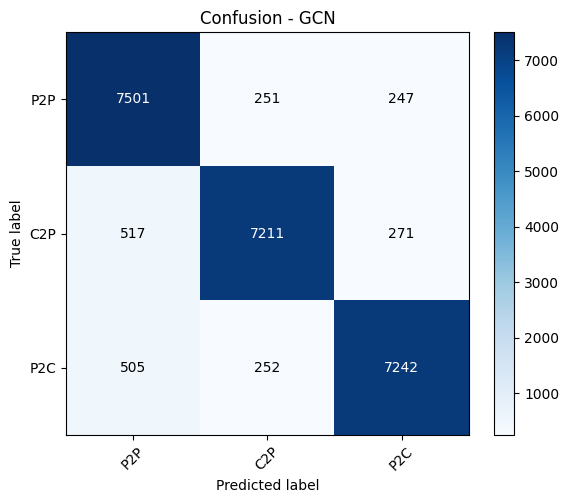

Normalized confusion matrix (%)


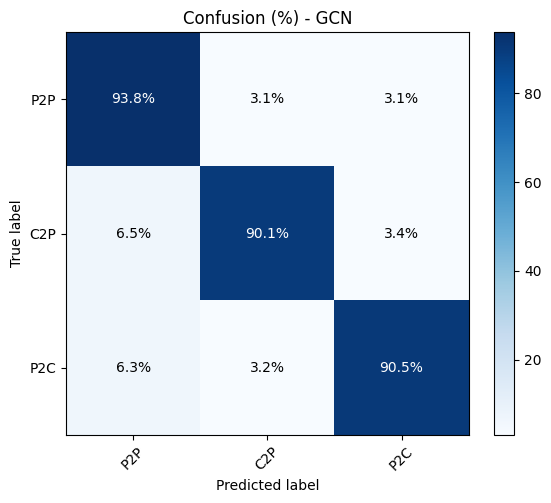

              precision    recall  f1-score   support

         P2P     0.8801    0.9377    0.9080      7999
         C2P     0.9348    0.9015    0.9178      7999
         P2C     0.9332    0.9054    0.9191      7999

    accuracy                         0.9149     23997
   macro avg     0.9160    0.9149    0.9150     23997
weighted avg     0.9160    0.9149    0.9150     23997

[BASELINE] Majority class=0 (P2P)
[BASELINE] Acc=33.33% | Macro-F1=16.67%
[MODEL]    Acc=91.49% | Macro-F1=91.50%
Recall per class (test):
  - P2P: 93.77%
  - C2P: 90.15%
  - P2C: 90.54%


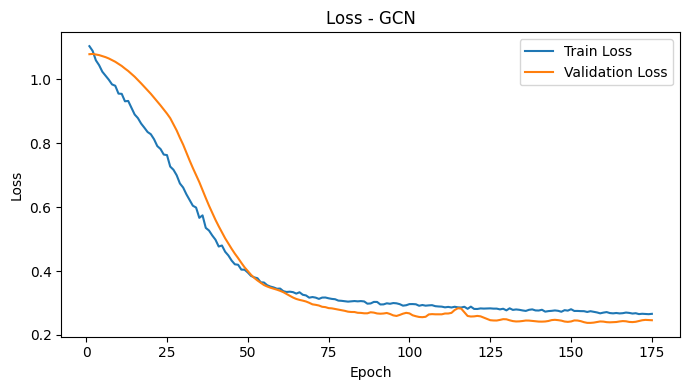

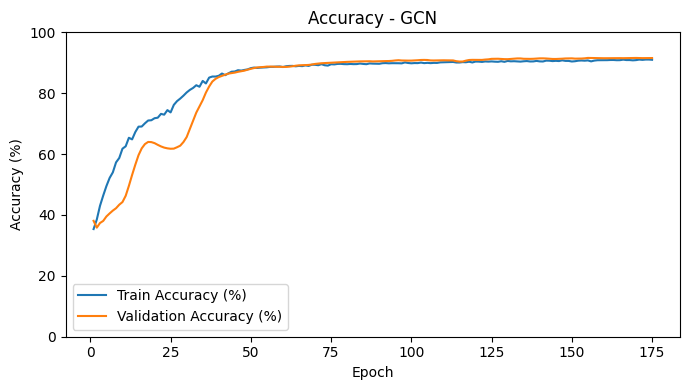

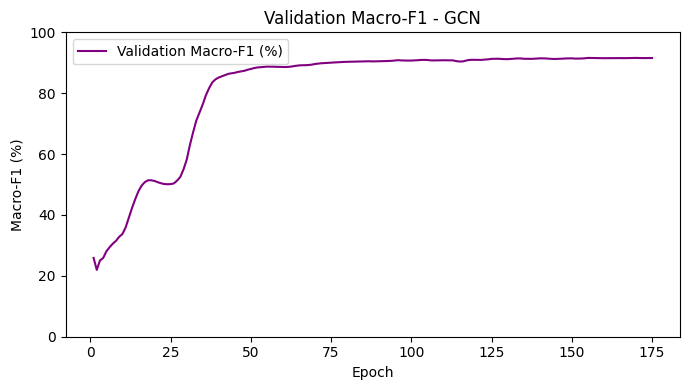


=== Training GraphSAGE (MLP Decoder) ===
ep001 | loss_tr 1.1341 acc_tr 33.46% | loss_val 1.1068 acc_val 30.69% f1_val 23.64%
ep010 | loss_tr 1.0122 acc_tr 50.71% | loss_val 1.0547 acc_val 47.20% f1_val 44.49%
ep020 | loss_tr 0.8799 acc_tr 61.34% | loss_val 0.8915 acc_val 63.84% f1_val 64.00%
ep030 | loss_tr 0.7464 acc_tr 71.16% | loss_val 0.7167 acc_val 71.92% f1_val 72.26%
ep040 | loss_tr 0.6650 acc_tr 74.31% | loss_val 0.6066 acc_val 76.41% f1_val 76.69%
ep050 | loss_tr 0.5788 acc_tr 78.67% | loss_val 0.5223 acc_val 80.64% f1_val 80.74%
ep060 | loss_tr 0.5209 acc_tr 81.00% | loss_val 0.4955 acc_val 80.99% f1_val 80.82%
ep070 | loss_tr 0.4844 acc_tr 82.30% | loss_val 0.4675 acc_val 82.14% f1_val 81.96%
ep080 | loss_tr 0.4534 acc_tr 83.50% | loss_val 0.4346 acc_val 83.79% f1_val 83.68%
ep090 | loss_tr 0.4254 acc_tr 84.53% | loss_val 0.3826 acc_val 86.01% f1_val 86.01%
ep100 | loss_tr 0.3913 acc_tr 86.07% | loss_val 0.3471 acc_val 87.59% f1_val 87.60%
ep110 | loss_tr 0.3710 acc_tr 86.9

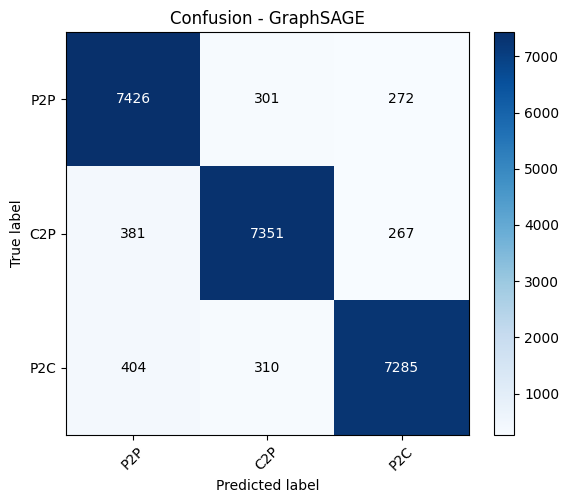

Normalized confusion matrix (%)


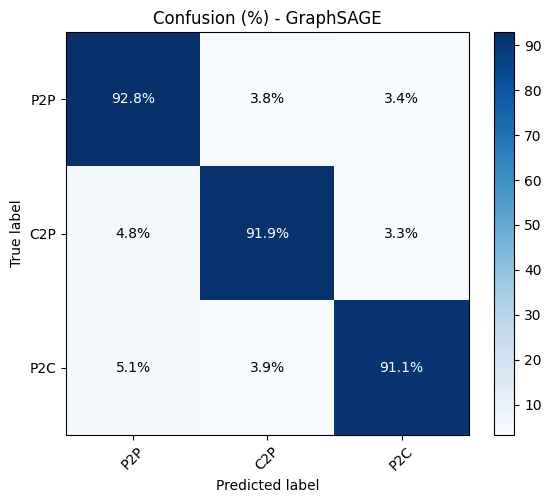

              precision    recall  f1-score   support

         P2P     0.9044    0.9284    0.9162      7999
         C2P     0.9233    0.9190    0.9211      7999
         P2C     0.9311    0.9107    0.9208      7999

    accuracy                         0.9194     23997
   macro avg     0.9196    0.9194    0.9194     23997
weighted avg     0.9196    0.9194    0.9194     23997

[BASELINE] Majority class=0 (P2P)
[BASELINE] Acc=33.33% | Macro-F1=16.67%
[MODEL]    Acc=91.94% | Macro-F1=91.94%
Recall per class (test):
  - P2P: 92.84%
  - C2P: 91.90%
  - P2C: 91.07%


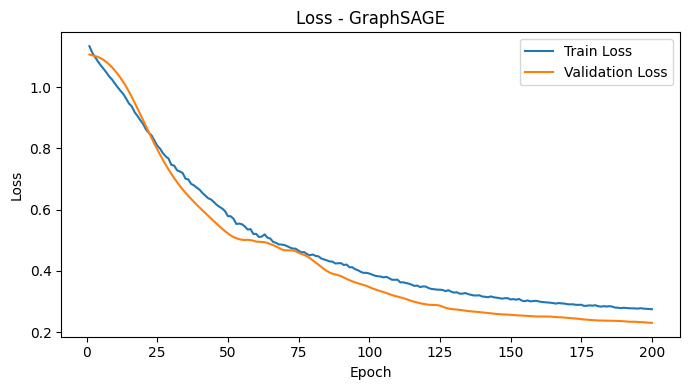

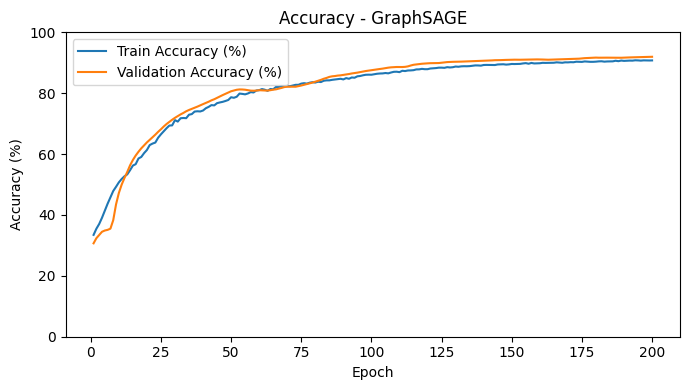

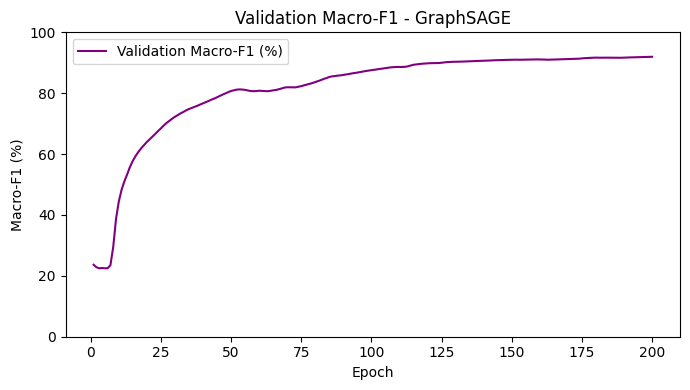


=== Training GAT (MLP Decoder) ===
ep001 | loss_tr 1.1097 acc_tr 32.95% | loss_val 1.1016 acc_val 33.33% f1_val 16.67%
ep010 | loss_tr 0.9121 acc_tr 61.24% | loss_val 1.0845 acc_val 35.55% f1_val 24.15%
ep020 | loss_tr 0.7947 acc_tr 66.83% | loss_val 1.0017 acc_val 58.18% f1_val 56.86%
ep030 | loss_tr 0.6956 acc_tr 72.91% | loss_val 0.8071 acc_val 74.82% f1_val 75.25%
ep040 | loss_tr 0.5680 acc_tr 80.04% | loss_val 0.6014 acc_val 81.93% f1_val 82.15%
ep050 | loss_tr 0.4726 acc_tr 83.69% | loss_val 0.4358 acc_val 85.07% f1_val 85.14%
ep060 | loss_tr 0.4190 acc_tr 85.14% | loss_val 0.3705 acc_val 86.43% f1_val 86.51%
ep070 | loss_tr 0.3913 acc_tr 86.31% | loss_val 0.3418 acc_val 87.59% f1_val 87.66%
ep080 | loss_tr 0.3659 acc_tr 87.46% | loss_val 0.3162 acc_val 88.71% f1_val 88.76%
ep090 | loss_tr 0.3377 acc_tr 88.92% | loss_val 0.2863 acc_val 90.41% f1_val 90.42%
ep100 | loss_tr 0.3134 acc_tr 89.79% | loss_val 0.2670 acc_val 91.21% f1_val 91.21%
ep110 | loss_tr 0.2972 acc_tr 90.43% | l

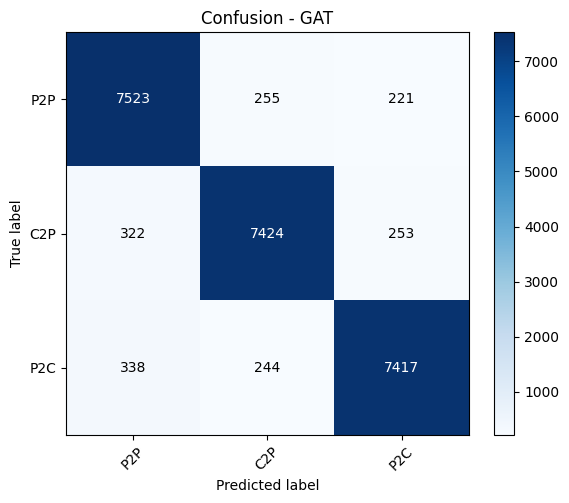

Normalized confusion matrix (%)


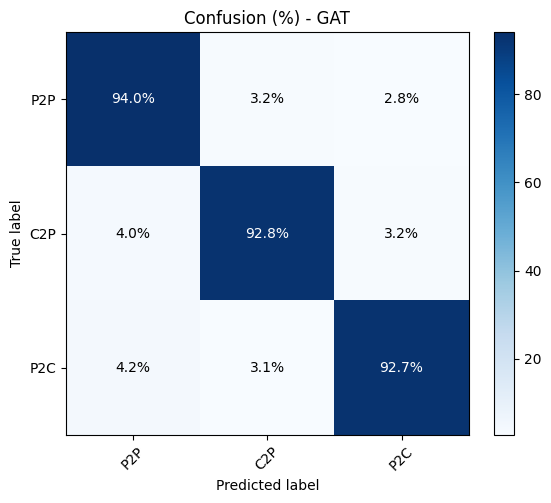

              precision    recall  f1-score   support

         P2P     0.9193    0.9405    0.9298      7999
         C2P     0.9370    0.9281    0.9325      7999
         P2C     0.9399    0.9272    0.9335      7999

    accuracy                         0.9319     23997
   macro avg     0.9321    0.9319    0.9320     23997
weighted avg     0.9321    0.9319    0.9320     23997

[BASELINE] Majority class=0 (P2P)
[BASELINE] Acc=33.33% | Macro-F1=16.67%
[MODEL]    Acc=93.19% | Macro-F1=93.20%
Recall per class (test):
  - P2P: 94.05%
  - C2P: 92.81%
  - P2C: 92.72%


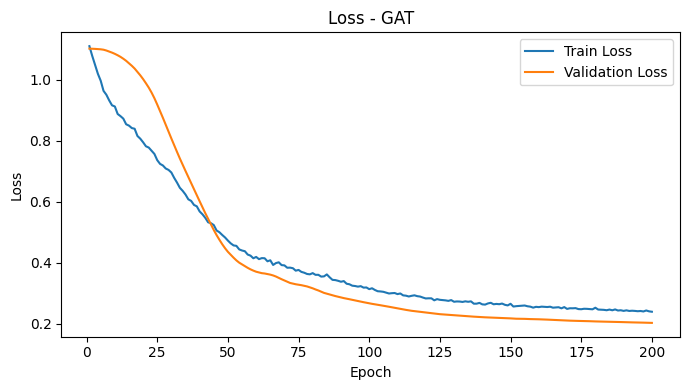

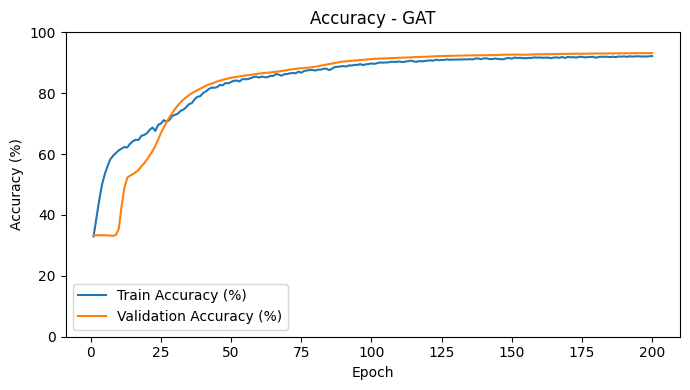

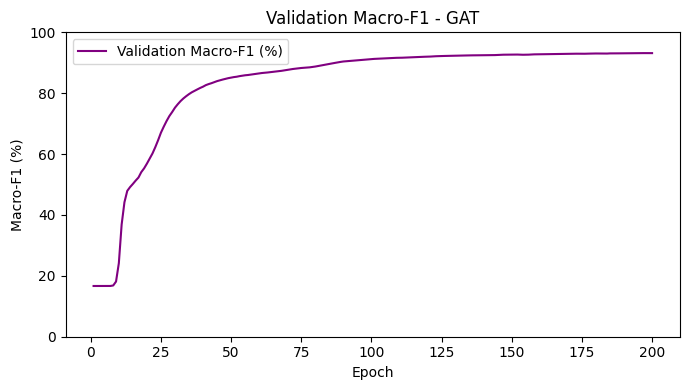

In [29]:
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
import matplotlib.pyplot as plt

# Global parameters (use unified config)
in_feats  = gnn.dgl_graph.ndata["feat"].shape[1]
device    = "cuda" if torch.cuda.is_available() else "cpu"
lr        = LR
patience  = PATIENCE

# Data and masks
g       = gnn.dgl_graph.to(device)
feat    = g.ndata["feat"].to(device)
label_key = next((k for k in ["label", "relationship", "Relationship"] if k in g.edata), None)
if label_key is None:
    raise KeyError(f"Label column not found in edata. Available keys: {list(g.edata.keys())}")

labels  = g.edata[label_key].long().to(device)
train_m = g.edata["train_mask"].bool().to(device)
val_m   = g.edata["val_mask"].bool().to(device) if "val_mask" in g.edata else None
test_m  = g.edata["test_mask"].bool().to(device)

if val_m is None or val_m.sum().item() == 0:
    raise ValueError("val_mask is empty/not found. Use split_edges_classification with val_size > 0.")

labeled_m = train_m | val_m | test_m
n_classes = int(labels[labeled_m].max().item()) + 1

class_counts = torch.bincount(labels[train_m], minlength=n_classes).float()
class_weights = (class_counts.sum() / (n_classes * class_counts.clamp(min=1.0))).to(device)

default_names = ["P2P", "C2P", "P2C"]
class_names = default_names[:n_classes] if n_classes <= len(default_names) else [f"Class {i}" for i in range(n_classes)]

for name, Model in models.items():
    print(f"\n=== Training {name} (MLP Decoder) ===")

    model = Model(in_feats, HIDDEN_DIM, OUT_DIM, out_feats_mlp=n_classes).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    hist = {"loss_tr": [], "acc_tr": [], "loss_val": [], "acc_val": [], "f1_val": []}
    best_macro_f1, best_loss, wait, best_w = -1.0, float("inf"), 0, None

    for ep in range(1, NUM_EPOCHS + 1):
        model.train()
        h = model.encode(g, feat)
        logits = model.decodeMLP(g, h)

        loss = F.cross_entropy(logits[train_m], labels[train_m], weight=class_weights)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        opt.step()

        with torch.no_grad():
            preds_tr = logits[train_m].argmax(1)
            acc_tr = (preds_tr == labels[train_m]).float().mean().item()

        model.eval()
        with torch.no_grad():
            logits_t = model.decodeMLP(g, model.encode(g, feat))
            loss_val = F.cross_entropy(logits_t[val_m], labels[val_m], weight=class_weights)
            preds_val = logits_t[val_m].argmax(1)
            val_true = labels[val_m]
            acc_val = (preds_val == val_true).float().mean().item()
            macro_f1_val = f1_score(
                val_true.cpu().numpy(),
                preds_val.cpu().numpy(),
                average="macro",
                zero_division=0,
            )

        hist["loss_tr"].append(loss.item())
        hist["acc_tr"].append(acc_tr * 100)
        hist["loss_val"].append(loss_val.item())
        hist["acc_val"].append(acc_val * 100)
        hist["f1_val"].append(macro_f1_val * 100)

        improved_f1 = macro_f1_val > (best_macro_f1 + 1e-4)
        tie_break_loss = abs(macro_f1_val - best_macro_f1) <= 1e-4 and loss_val.item() < (best_loss - 1e-4)

        if improved_f1 or tie_break_loss:
            best_macro_f1, best_loss, wait = macro_f1_val, loss_val.item(), 0
            best_w = model.state_dict()
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stop at epoch {ep} (best val macro-F1={best_macro_f1*100:.2f}%)")
                break

        if ep % 10 == 0 or ep == 1:
            print(
                f"ep{ep:03d} | loss_tr {loss:.4f} acc_tr {acc_tr:.2%} | "
                f"loss_val {loss_val:.4f} acc_val {acc_val:.2%} f1_val {macro_f1_val:.2%}"
            )

    if best_w is not None:
        model.load_state_dict(best_w)

    with torch.no_grad():
        logits_best = model.decodeMLP(g, model.encode(g, feat))
        preds_best = logits_best[test_m].argmax(1).cpu()
        truth = labels[test_m].cpu()

    cm = confusion_matrix(truth, preds_best, labels=list(range(n_classes)))
    plot_confusion_matrix_2(cm, class_names, False, title=f"Confusion - {name}")
    plot_confusion_matrix_2(cm, class_names, True, title=f"Confusion (%) - {name}")

    print(classification_report(truth, preds_best, digits=4, zero_division=0, target_names=class_names))

    majority_class = int(torch.mode(labels[train_m]).values.item())
    baseline_preds = torch.full_like(truth, fill_value=majority_class)
    baseline_acc = accuracy_score(truth, baseline_preds) * 100
    baseline_f1_macro = f1_score(truth, baseline_preds, average="macro", zero_division=0) * 100

    recalls_per_class = recall_score(
        truth,
        preds_best,
        average=None,
        labels=list(range(n_classes)),
        zero_division=0,
    )

    model_acc = accuracy_score(truth, preds_best) * 100
    model_f1_macro = f1_score(truth, preds_best, average="macro", zero_division=0) * 100

    print(f"[BASELINE] Majority class={majority_class} ({class_names[majority_class] if majority_class < len(class_names) else majority_class})")
    print(f"[BASELINE] Acc={baseline_acc:.2f}% | Macro-F1={baseline_f1_macro:.2f}%")
    print(f"[MODEL]    Acc={model_acc:.2f}% | Macro-F1={model_f1_macro:.2f}%")

    print("Recall per class (test):")
    for i, r in enumerate(recalls_per_class):
        cname = class_names[i] if i < len(class_names) else f"Class {i}"
        print(f"  - {cname}: {r*100:.2f}%")

    epochs_done = range(1, len(hist["loss_tr"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_done, hist["loss_tr"], label="Train Loss")
    plt.plot(epochs_done, hist["loss_val"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_done, hist["acc_tr"], label="Train Accuracy (%)")
    plt.plot(epochs_done, hist["acc_val"], label="Validation Accuracy (%)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.title(f"Accuracy - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_done, hist["f1_val"], label="Validation Macro-F1 (%)", color="purple")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1 (%)")
    plt.ylim(0, 100)
    plt.title(f"Validation Macro-F1 - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Caso 1: Se utiliza grafo con atributos de centralidad

In [8]:
# 1. Load data with the new format (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset_only_cntrality_attr(str(nodes_file), str(edges_file))

gnn.split_edges_classification(
    train_size=0.8,
    val_size=0.15,
    seed=42,
    balance_mode="strict_equal",   # use "proportional" to keep natural class distribution
)

g0 = gnn.dgl_graph
print("\n[Loaded graph summary]")
print(f"- Nodes: {g0.num_nodes():,}")
print(f"- Edges: {g0.num_edges():,}")
print(f"- Feature dimension: {g0.ndata['feat'].shape[1]}")
print(f"- Edge data keys: {list(g0.edata.keys())}")
print(f"- Train edges: {g0.edata['train_mask'].sum().item():,}")
print(f"- Validation edges: {g0.edata['val_mask'].sum().item():,}")
print(f"- Test edges: {g0.edata['test_mask'].sum().item():,}")
if "label" in g0.edata:
    print(f"- Global label distribution: {Counter(g0.edata['label'].tolist())}")
    tr = g0.edata['label'][g0.edata['train_mask']]
    va = g0.edata['label'][g0.edata['val_mask']]
    te = g0.edata['label'][g0.edata['test_mask']]
    print(f"- Train distribution: {Counter(tr.tolist())}")
    print(f"- Validation distribution: {Counter(va.tolist())}")
    print(f"- Test distribution: {Counter(te.tolist())}")


Grafo cargado: 79504 nodos, 734381 aristas
Features usadas (5): ['weight', 'PageRank', 'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality']
Dimensión de entrada (in_feats): 5

[SPLIT COMPLETO - ESTRATIFICADO]
Modo balanceo: strict_equal
Etiqueta usada: label
Total aristas etiquetadas: 660438
Train: 383910 | Val: 71982 | Test: 23997
Distribución Train: {1: 127970, 0: 127970, 2: 127970}
Distribución Val:   {0: 23994, 2: 23994, 1: 23994}
Distribución Test:  {2: 7999, 1: 7999, 0: 7999}

[Loaded graph summary]
- Nodes: 79,504
- Edges: 734,381
- Feature dimension: 5
- Edge data keys: ['label', 'train_mask', 'val_mask', 'test_mask']
- Train edges: 383,910
- Validation edges: 71,982
- Test edges: 23,997
- Global label distribution: Counter({0: 340512, 1: 159963, 2: 159963, -1: 73943})
- Train distribution: Counter({1: 127970, 2: 127970, 0: 127970})
- Validation distribution: Counter({1: 23994, 0: 23994, 2: 23994})
- Test distribution: Counter({1: 7999, 0: 7999, 2: 7999})


### Decode: DotProduct

In [9]:
# Modelos a entrenar
models = {
    'GCN': GCN,
    'GraphSAGE': GraphSAGE,
    'GAT': GAT,
}
models_dict = models  # alias por compatibilidad

# Configuración de entrenamiento (estable)
LR = 1e-3
HIDDEN_DIM = 64
OUT_DIM = 32
PATIENCE = 20
NUM_EPOCHS = 200

In [ ]:
# 1.- Definición parámetros (usar config global)
# ----------------------------------------------
in_feats      = gnn.dgl_graph.ndata["feat"].shape[1]
hidden_feats  = HIDDEN_DIM
emb_dim       = OUT_DIM
lr            = LR
lr_bilinear   = 1e-4          # Bilinear needs lower LR: W is quadratic in h_dim
device        = "cuda" if torch.cuda.is_available() else "cpu"

# 2.- Datos y máscaras
# ----------------------------------------------
g       = gnn.dgl_graph.to(device)
feat    = g.ndata["feat"].to(device)

In [ ]:

label_key = next((k for k in ["label", "relationship", "Relationship"] if k in g.edata), None)
if label_key is None:
    raise KeyError(f"Label column not found in edata. Available keys: {list(g.edata.keys())}")
labels = g.edata[label_key].long().to(device)

train_m = g.edata["train_mask"].bool().to(device)
val_m   = g.edata["val_mask"].bool().to(device) if "val_mask" in g.edata else None
test_m  = g.edata["test_mask"].bool().to(device)

if train_m.sum().item() == 0 or test_m.sum().item() == 0:
    raise ValueError("train_mask/test_mask are empty. Check split_edges_classification().")
if val_m is None or val_m.sum().item() == 0:
    raise ValueError("val_mask is empty/not found. Use split_edges_classification with val_size > 0.")

labeled_m = train_m | val_m | test_m
n_classes = int(labels[labeled_m].max().item()) + 1

# Class weights to reduce collapse into a dominant class
class_counts = torch.bincount(labels[train_m], minlength=n_classes).float()
class_weights = (class_counts.sum() / (n_classes * class_counts.clamp(min=1.0))).to(device)

default_names = ["P2P", "C2P", "P2C"]
class_names = default_names[:n_classes] if n_classes <= len(default_names) else [f"Class {i}" for i in range(n_classes)]

print(f"Using device: {device}")
print(f"Using edge label key: {label_key}")
print(f"Number of classes detected: {n_classes}")
print(f"Train class counts: {class_counts.tolist()}")
print(f"Class weights: {class_weights.tolist()}")

# 3.- Load node_id -> asn mapping for readable inference export
id_to_asn = {}
with open(nodes_file, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        id_to_asn[int(row["node_id"])] = int(row["asn"])

# 4.- Output directories
output_root = Path("./results/end_to_end")
plot_dir = output_root / "plots"
pred_dir = output_root / "predictions"
plot_dir.mkdir(parents=True, exist_ok=True)
pred_dir.mkdir(parents=True, exist_ok=True)
run_tag = edges_file.stem.replace("edges_", "")

# 5.- Training per model (Bilinear Decoder)
for name, Model in models.items():
    print(f"\nTraining {name} (Bilinear)\n" + "-" * 40)

    history = {"loss_tr": [], "acc_tr": [], "loss_val": [], "acc_val": [], "f1_val": []}
    model = Model(in_feats, hidden_feats, emb_dim, out_feats_mlp=n_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr_bilinear, weight_decay=1e-5)

    best_macro_f1, best_val_loss, wait, best_w = -1.0, float("inf"), 0, None

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        h = model.encode(g, feat)
        logits = model.decodeBilinear(g, h)

        loss = F.cross_entropy(logits[train_m], labels[train_m], weight=class_weights)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        opt.step()

        with torch.no_grad():
            preds_tr = logits[train_m].argmax(1)
            acc_tr = (preds_tr == labels[train_m]).float().mean().item()

        model.eval()
        with torch.no_grad():
            logits_val = model.decodeBilinear(g, model.encode(g, feat))
            loss_val = F.cross_entropy(logits_val[val_m], labels[val_m], weight=class_weights)
            preds_val = logits_val[val_m].argmax(1)
            val_true = labels[val_m]
            acc_val = (preds_val == val_true).float().mean().item()
            macro_f1_val = f1_score(
                val_true.cpu().numpy(),
                preds_val.cpu().numpy(),
                average="macro",
                zero_division=0,
            )

        history["loss_tr"].append(loss.item())
        history["acc_tr"].append(acc_tr * 100)
        history["loss_val"].append(loss_val.item())
        history["acc_val"].append(acc_val * 100)
        history["f1_val"].append(macro_f1_val * 100)

        improved_f1 = macro_f1_val > (best_macro_f1 + 1e-4)
        tie_break_loss = abs(macro_f1_val - best_macro_f1) <= 1e-4 and loss_val.item() < (best_val_loss - 1e-4)

        if improved_f1 or tie_break_loss:
            best_macro_f1, best_val_loss, wait = macro_f1_val, loss_val.item(), 0
            best_w = model.state_dict()
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early stop at epoch {epoch} (best val macro-F1={best_macro_f1*100:.2f}%)")
                break

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"ep{epoch:03d} | loss_tr {loss:.4f} acc_tr {acc_tr:.2%} | "
                f"loss_val {loss_val:.4f} acc_val {acc_val:.2%} f1_val {macro_f1_val:.2%}"
            )

    if best_w is not None:
        model.load_state_dict(best_w)

    with torch.no_grad():
        logits_best = model.decodeBilinear(g, model.encode(g, feat))
        preds_best = logits_best[test_m].argmax(1).cpu()
        truth = labels[test_m].cpu()

    cm = confusion_matrix(truth, preds_best, labels=list(range(n_classes)))
    plot_confusion_matrix_2(cm, classes=class_names, normalize=False, title=f"Confusion Matrix - {name}")
    plot_confusion_matrix_2(cm, classes=class_names, normalize=True, title=f"Confusion Matrix (%) - {name}")

    print(classification_report(truth, preds_best, digits=4, zero_division=0, target_names=class_names))

    # Baseline: always predict the majority train class
    majority_class = int(torch.mode(labels[train_m]).values.item())
    baseline_preds = torch.full_like(truth, fill_value=majority_class)
    baseline_acc = accuracy_score(truth, baseline_preds) * 100
    baseline_f1_macro = f1_score(truth, baseline_preds, average="macro", zero_division=0) * 100

    prec_micro = precision_score(truth, preds_best, average="micro", zero_division=0) * 100
    rec_micro  = recall_score(truth, preds_best, average="micro", zero_division=0) * 100
    f1_micro   = f1_score(truth, preds_best, average="micro", zero_division=0) * 100
    acc        = accuracy_score(truth, preds_best) * 100

    prec_macro = precision_score(truth, preds_best, average="macro", zero_division=0) * 100
    rec_macro  = recall_score(truth, preds_best, average="macro", zero_division=0) * 100
    f1_macro   = f1_score(truth, preds_best, average="macro", zero_division=0) * 100

    prec_w = precision_score(truth, preds_best, average="weighted", zero_division=0) * 100
    rec_w  = recall_score(truth, preds_best, average="weighted", zero_division=0) * 100
    f1_w   = f1_score(truth, preds_best, average="weighted", zero_division=0) * 100

    recalls_per_class = recall_score(
        truth,
        preds_best,
        average=None,
        labels=list(range(n_classes)),
        zero_division=0,
    )

    print(f"[BASELINE] Majority class={majority_class} ({class_names[majority_class] if majority_class < len(class_names) else majority_class})")
    print(f"[BASELINE] Acc={baseline_acc:.2f}% | Macro-F1={baseline_f1_macro:.2f}%")
    print(f"[MODEL]    Acc={acc:.2f}% | Macro-F1={f1_macro:.2f}%")
    print(f"[TEST] micro:    Prec={prec_micro:.2f}%  Rec={rec_micro:.2f}%  F1={f1_micro:.2f}% | Acc={acc:.2f}%")
    print(f"[TEST] macro:    Prec={prec_macro:.2f}%  Rec={rec_macro:.2f}%  F1={f1_macro:.2f}%")
    print(f"[TEST] weighted: Prec={prec_w:.2f}%  Rec={rec_w:.2f}%  F1={f1_w:.2f}%")

    print("Recall per class (test):")
    for i, r in enumerate(recalls_per_class):
        cname = class_names[i] if i < len(class_names) else f"Class {i}"
        print(f"  - {cname}: {r*100:.2f}%")

    epoch_axis = range(1, len(history["loss_tr"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epoch_axis, history["loss_tr"], label="Train Loss")
    plt.plot(epoch_axis, history["loss_val"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"loss_{name}_{run_tag}_bilinear.png", dpi=300, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epoch_axis, history["acc_tr"], label="Train Accuracy (%)")
    plt.plot(epoch_axis, history["acc_val"], label="Validation Accuracy (%)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy Curve - {name}")
    plt.ylim(0, 100)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"accuracy_{name}_{run_tag}_bilinear.png", dpi=300, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epoch_axis, history["f1_val"], label="Validation Macro-F1 (%)", color="purple")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1 (%)")
    plt.title(f"Validation Macro-F1 Curve - {name}")
    plt.ylim(0, 100)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"macrof1_val_{name}_{run_tag}_bilinear.png", dpi=300, bbox_inches='tight')
    plt.show()

    out_file = pred_dir / f"inference_results_{name}_{run_tag}_bilinear.txt"
    u, v = g.edges()
    test_eids = torch.where(test_m)[0].cpu().tolist()
    with open(out_file, "w") as f:
        f.write("src_id|dst_id|src_asn|dst_asn|pred|real\n")
        for i, eidx in enumerate(test_eids):
            src_id = int(u[eidx].item())
            dst_id = int(v[eidx].item())
            src_asn = id_to_asn.get(src_id, -1)
            dst_asn = id_to_asn.get(dst_id, -1)
            pred = int(preds_best[i].item())
            real = int(truth[i].item())
            f.write(f"{src_id}|{dst_id}|{src_asn}|{dst_asn}|{pred}|{real}\n")

    print(f"Inference file saved at: {out_file}")

### Decode: MLP


=== Training GCN (MLP Decoder) ===
ep001 | loss_tr 1.1174 acc_tr 25.45% | loss_val 1.0996 acc_val 33.18% f1_val 17.35%
ep010 | loss_tr 0.9854 acc_tr 61.89% | loss_val 1.0856 acc_val 41.88% f1_val 30.61%
ep020 | loss_tr 0.8686 acc_tr 68.68% | loss_val 1.0527 acc_val 46.84% f1_val 36.01%
Early stop at epoch 25 (best val macro-F1=42.29%)
Confusion matrix (not normalized)


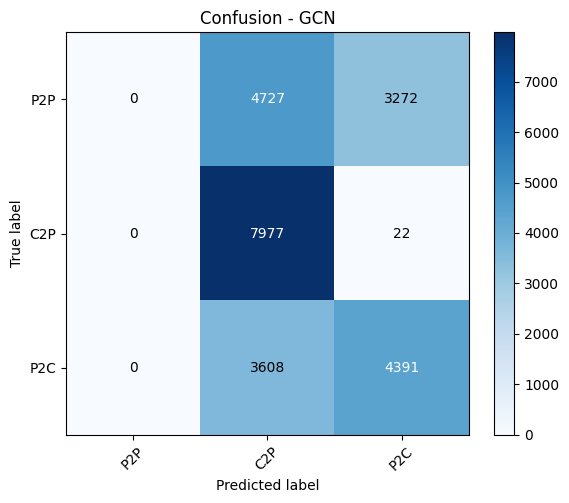

Normalized confusion matrix (%)


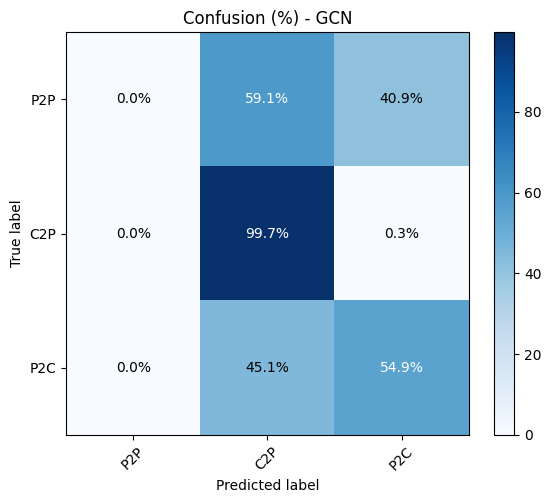

              precision    recall  f1-score   support

         P2P     0.0000    0.0000    0.0000      7999
         C2P     0.4890    0.9972    0.6562      7999
         P2C     0.5714    0.5489    0.5599      7999

    accuracy                         0.5154     23997
   macro avg     0.3535    0.5154    0.4054     23997
weighted avg     0.3535    0.5154    0.4054     23997

[BASELINE] Majority class=0 (P2P)
[BASELINE] Acc=33.33% | Macro-F1=16.67%
[MODEL]    Acc=51.54% | Macro-F1=40.54%
Recall per class (test):
  - P2P: 0.00%
  - C2P: 99.72%
  - P2C: 54.89%


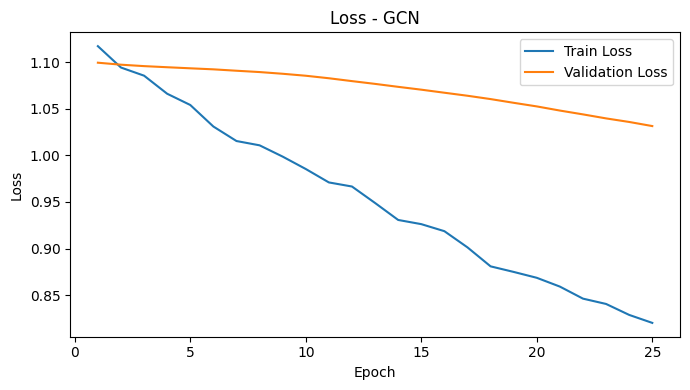

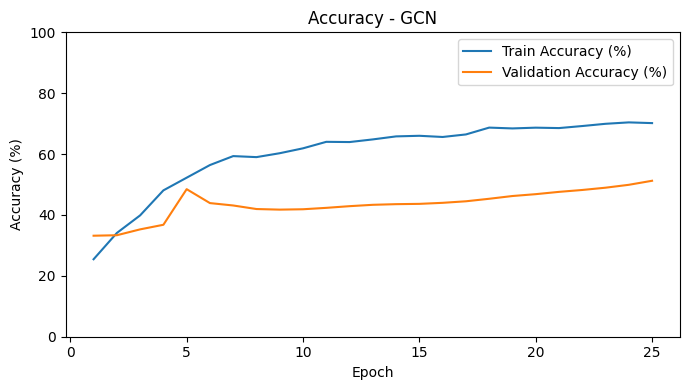

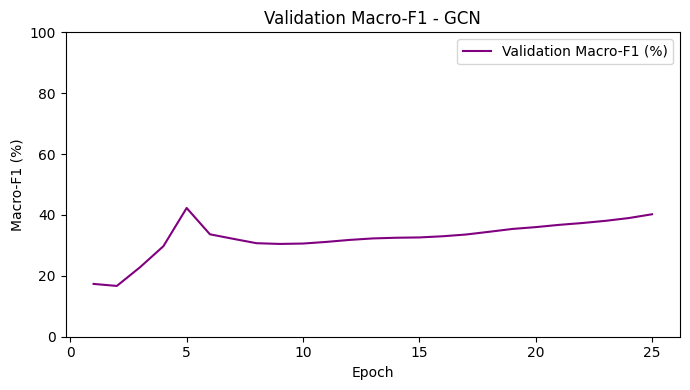


=== Training GraphSAGE (MLP Decoder) ===
ep001 | loss_tr 1.1180 acc_tr 32.18% | loss_val 1.0990 acc_val 33.33% f1_val 16.67%
ep010 | loss_tr 1.0300 acc_tr 50.41% | loss_val 1.0983 acc_val 33.80% f1_val 17.67%
ep020 | loss_tr 0.9440 acc_tr 60.05% | loss_val 1.0909 acc_val 39.69% f1_val 28.71%
ep030 | loss_tr 0.8449 acc_tr 65.31% | loss_val 1.0444 acc_val 49.78% f1_val 44.29%
ep040 | loss_tr 0.7596 acc_tr 69.11% | loss_val 0.9355 acc_val 57.41% f1_val 55.02%
ep050 | loss_tr 0.6983 acc_tr 71.81% | loss_val 0.8170 acc_val 65.28% f1_val 64.67%
ep060 | loss_tr 0.6571 acc_tr 73.84% | loss_val 0.6993 acc_val 75.79% f1_val 75.88%
ep070 | loss_tr 0.6211 acc_tr 75.49% | loss_val 0.6849 acc_val 70.55% f1_val 68.47%
Early stop at epoch 80 (best val macro-F1=75.88%)
Confusion matrix (not normalized)


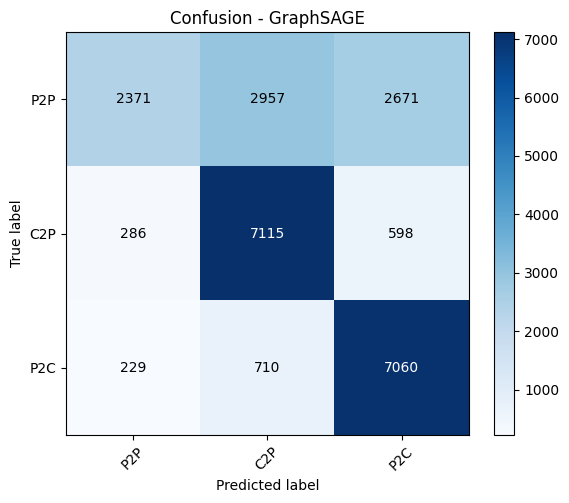

Normalized confusion matrix (%)


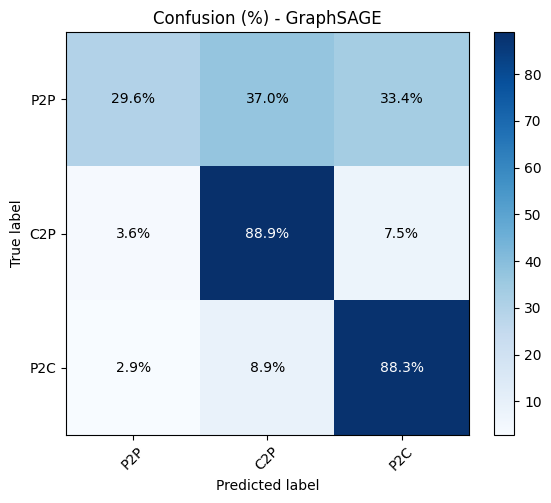

              precision    recall  f1-score   support

         P2P     0.8216    0.2964    0.4356      7999
         C2P     0.6599    0.8895    0.7577      7999
         P2C     0.6835    0.8826    0.7704      7999

    accuracy                         0.6895     23997
   macro avg     0.7217    0.6895    0.6546     23997
weighted avg     0.7217    0.6895    0.6546     23997

[BASELINE] Majority class=0 (P2P)
[BASELINE] Acc=33.33% | Macro-F1=16.67%
[MODEL]    Acc=68.95% | Macro-F1=65.46%
Recall per class (test):
  - P2P: 29.64%
  - C2P: 88.95%
  - P2C: 88.26%


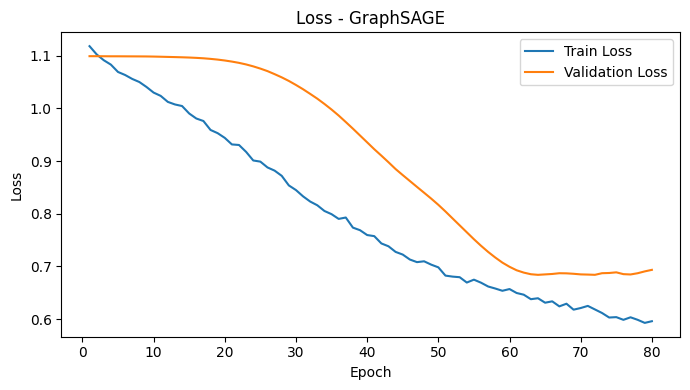

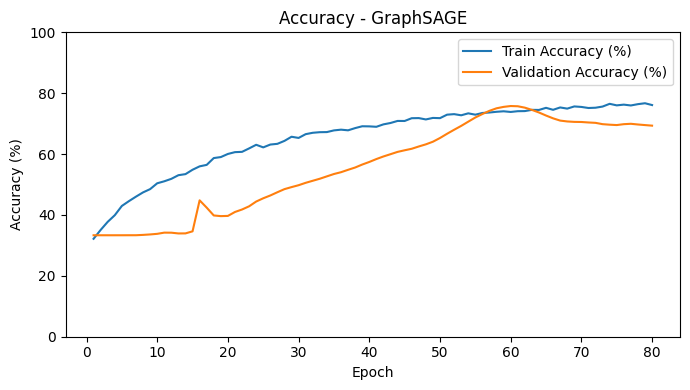

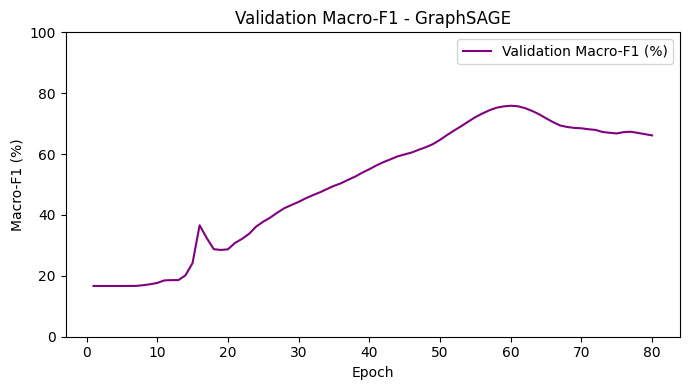


=== Training GAT (MLP Decoder) ===
ep001 | loss_tr 1.1115 acc_tr 33.18% | loss_val 1.1049 acc_val 33.33% f1_val 16.67%
ep010 | loss_tr 1.0393 acc_tr 42.37% | loss_val 1.1030 acc_val 33.33% f1_val 16.67%
ep020 | loss_tr 0.9500 acc_tr 54.54% | loss_val 1.1001 acc_val 33.33% f1_val 16.67%
ep030 | loss_tr 0.8749 acc_tr 60.69% | loss_val 1.0945 acc_val 36.58% f1_val 23.44%
ep040 | loss_tr 0.7882 acc_tr 62.68% | loss_val 1.0704 acc_val 51.59% f1_val 41.45%
ep050 | loss_tr 0.7186 acc_tr 66.94% | loss_val 0.9762 acc_val 58.04% f1_val 46.62%
ep060 | loss_tr 0.6689 acc_tr 70.19% | loss_val 0.8708 acc_val 60.39% f1_val 48.52%
ep070 | loss_tr 0.6438 acc_tr 72.21% | loss_val 0.7670 acc_val 62.49% f1_val 53.20%
ep080 | loss_tr 0.6324 acc_tr 74.58% | loss_val 0.6586 acc_val 70.89% f1_val 67.99%
ep090 | loss_tr 0.5956 acc_tr 76.07% | loss_val 0.5917 acc_val 76.39% f1_val 75.38%
ep100 | loss_tr 0.5673 acc_tr 78.02% | loss_val 0.5561 acc_val 77.92% f1_val 77.19%
ep110 | loss_tr 0.5497 acc_tr 78.63% | l

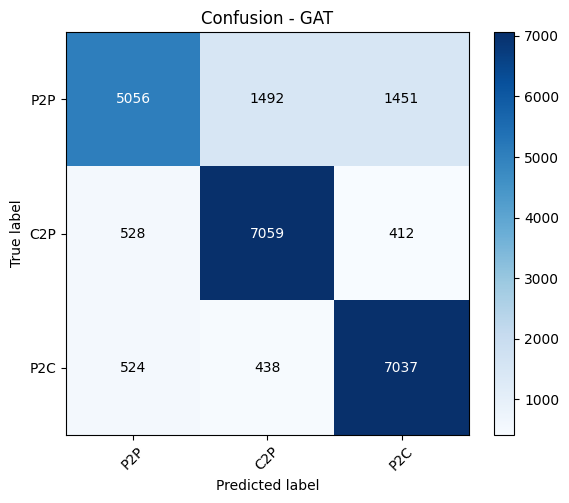

Normalized confusion matrix (%)


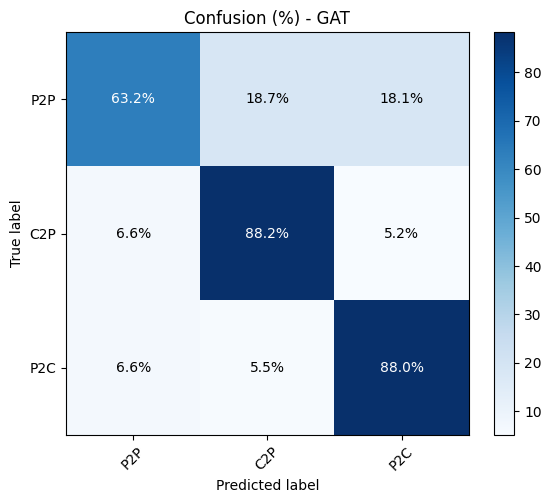

              precision    recall  f1-score   support

         P2P     0.8278    0.6321    0.7168      7999
         C2P     0.7853    0.8825    0.8311      7999
         P2C     0.7907    0.8797    0.8328      7999

    accuracy                         0.7981     23997
   macro avg     0.8012    0.7981    0.7936     23997
weighted avg     0.8012    0.7981    0.7936     23997

[BASELINE] Majority class=0 (P2P)
[BASELINE] Acc=33.33% | Macro-F1=16.67%
[MODEL]    Acc=79.81% | Macro-F1=79.36%
Recall per class (test):
  - P2P: 63.21%
  - C2P: 88.25%
  - P2C: 87.97%


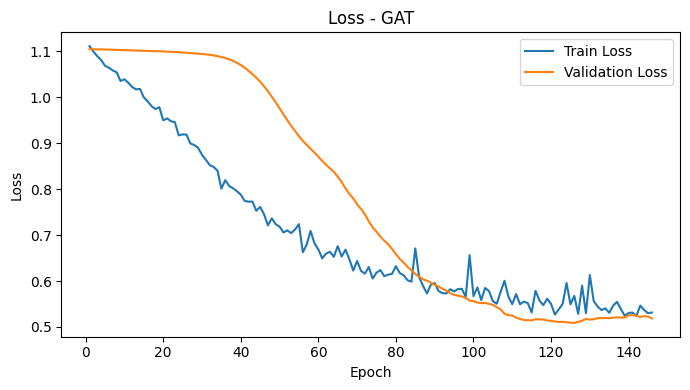

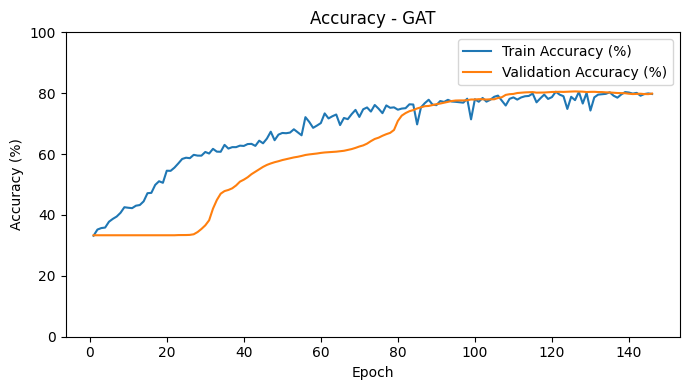

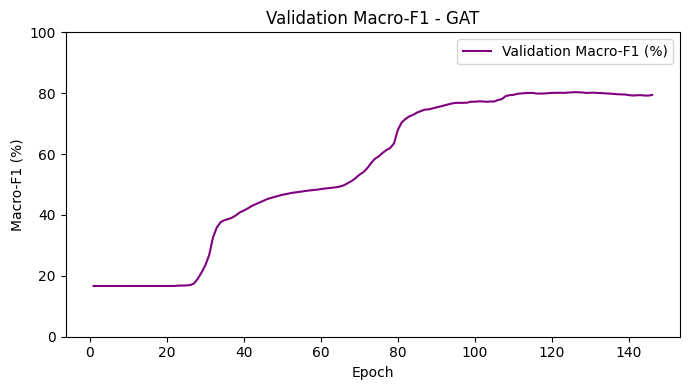

In [12]:
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
import matplotlib.pyplot as plt

# Global parameters (use unified config)
in_feats  = gnn.dgl_graph.ndata["feat"].shape[1]
device    = "cuda" if torch.cuda.is_available() else "cpu"
lr        = LR
patience  = PATIENCE

# Data and masks
g       = gnn.dgl_graph.to(device)
feat    = g.ndata["feat"].to(device)
label_key = next((k for k in ["label", "relationship", "Relationship"] if k in g.edata), None)
if label_key is None:
    raise KeyError(f"Label column not found in edata. Available keys: {list(g.edata.keys())}")

labels  = g.edata[label_key].long().to(device)
train_m = g.edata["train_mask"].bool().to(device)
val_m   = g.edata["val_mask"].bool().to(device) if "val_mask" in g.edata else None
test_m  = g.edata["test_mask"].bool().to(device)

if val_m is None or val_m.sum().item() == 0:
    raise ValueError("val_mask is empty/not found. Use split_edges_classification with val_size > 0.")

labeled_m = train_m | val_m | test_m
n_classes = int(labels[labeled_m].max().item()) + 1

class_counts = torch.bincount(labels[train_m], minlength=n_classes).float()
class_weights = (class_counts.sum() / (n_classes * class_counts.clamp(min=1.0))).to(device)

default_names = ["P2P", "C2P", "P2C"]
class_names = default_names[:n_classes] if n_classes <= len(default_names) else [f"Class {i}" for i in range(n_classes)]

for name, Model in models.items():
    print(f"\n=== Training {name} (MLP Decoder) ===")

    model = Model(in_feats, HIDDEN_DIM, OUT_DIM, out_feats_mlp=n_classes).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    hist = {"loss_tr": [], "acc_tr": [], "loss_val": [], "acc_val": [], "f1_val": []}
    best_macro_f1, best_loss, wait, best_w = -1.0, float("inf"), 0, None

    for ep in range(1, NUM_EPOCHS + 1):
        model.train()
        h = model.encode(g, feat)
        logits = model.decodeMLP(g, h)

        loss = F.cross_entropy(logits[train_m], labels[train_m], weight=class_weights)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        opt.step()

        with torch.no_grad():
            preds_tr = logits[train_m].argmax(1)
            acc_tr = (preds_tr == labels[train_m]).float().mean().item()

        model.eval()
        with torch.no_grad():
            logits_t = model.decodeMLP(g, model.encode(g, feat))
            loss_val = F.cross_entropy(logits_t[val_m], labels[val_m], weight=class_weights)
            preds_val = logits_t[val_m].argmax(1)
            val_true = labels[val_m]
            acc_val = (preds_val == val_true).float().mean().item()
            macro_f1_val = f1_score(
                val_true.cpu().numpy(),
                preds_val.cpu().numpy(),
                average="macro",
                zero_division=0,
            )

        hist["loss_tr"].append(loss.item())
        hist["acc_tr"].append(acc_tr * 100)
        hist["loss_val"].append(loss_val.item())
        hist["acc_val"].append(acc_val * 100)
        hist["f1_val"].append(macro_f1_val * 100)

        improved_f1 = macro_f1_val > (best_macro_f1 + 1e-4)
        tie_break_loss = abs(macro_f1_val - best_macro_f1) <= 1e-4 and loss_val.item() < (best_loss - 1e-4)

        if improved_f1 or tie_break_loss:
            best_macro_f1, best_loss, wait = macro_f1_val, loss_val.item(), 0
            best_w = model.state_dict()
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stop at epoch {ep} (best val macro-F1={best_macro_f1*100:.2f}%)")
                break

        if ep % 10 == 0 or ep == 1:
            print(
                f"ep{ep:03d} | loss_tr {loss:.4f} acc_tr {acc_tr:.2%} | "
                f"loss_val {loss_val:.4f} acc_val {acc_val:.2%} f1_val {macro_f1_val:.2%}"
            )

    if best_w is not None:
        model.load_state_dict(best_w)

    with torch.no_grad():
        logits_best = model.decodeMLP(g, model.encode(g, feat))
        preds_best = logits_best[test_m].argmax(1).cpu()
        truth = labels[test_m].cpu()

    cm = confusion_matrix(truth, preds_best, labels=list(range(n_classes)))
    plot_confusion_matrix_2(cm, class_names, False, title=f"Confusion - {name}")
    plot_confusion_matrix_2(cm, class_names, True, title=f"Confusion (%) - {name}")

    print(classification_report(truth, preds_best, digits=4, zero_division=0, target_names=class_names))

    majority_class = int(torch.mode(labels[train_m]).values.item())
    baseline_preds = torch.full_like(truth, fill_value=majority_class)
    baseline_acc = accuracy_score(truth, baseline_preds) * 100
    baseline_f1_macro = f1_score(truth, baseline_preds, average="macro", zero_division=0) * 100

    recalls_per_class = recall_score(
        truth,
        preds_best,
        average=None,
        labels=list(range(n_classes)),
        zero_division=0,
    )

    model_acc = accuracy_score(truth, preds_best) * 100
    model_f1_macro = f1_score(truth, preds_best, average="macro", zero_division=0) * 100

    print(f"[BASELINE] Majority class={majority_class} ({class_names[majority_class] if majority_class < len(class_names) else majority_class})")
    print(f"[BASELINE] Acc={baseline_acc:.2f}% | Macro-F1={baseline_f1_macro:.2f}%")
    print(f"[MODEL]    Acc={model_acc:.2f}% | Macro-F1={model_f1_macro:.2f}%")

    print("Recall per class (test):")
    for i, r in enumerate(recalls_per_class):
        cname = class_names[i] if i < len(class_names) else f"Class {i}"
        print(f"  - {cname}: {r*100:.2f}%")

    epochs_done = range(1, len(hist["loss_tr"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_done, hist["loss_tr"], label="Train Loss")
    plt.plot(epochs_done, hist["loss_val"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_done, hist["acc_tr"], label="Train Accuracy (%)")
    plt.plot(epochs_done, hist["acc_val"], label="Validation Accuracy (%)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.title(f"Accuracy - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs_done, hist["f1_val"], label="Validation Macro-F1 (%)", color="purple")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1 (%)")
    plt.ylim(0, 100)
    plt.title(f"Validation Macro-F1 - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Caso 2: Enfoque end-to-end utilizando grafo con atributos de PeeringDB y muestreo aleatorio de vecinos (Random Neighbour Sampling)

In [35]:
from modules.gnn_models import GCNSampler, GraphSAGESample, GATSample

models = {
    "GCN-Sampler":  GCNSampler,
    "SAGE-Sampler": GraphSAGESample,
    "GAT-Sampler":  GATSample
}


# Configuración de entrenamiento (estable)
LR = 1e-3
HIDDEN_DIM = 64
OUT_DIM = 32
PATIENCE = 20
NUM_EPOCHS = 200
N_NEIGHBORS = 10

In [36]:
# Cargar grafo con todos los atributos de nodos
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))

# Split estratificado sin fuga entre direcciones opuestas (store_eids=True por defecto)
gnn.split_edges_classification(
    train_size=0.8,
    val_size=0.15,
    seed=42,
    balance_mode="strict_equal",
)

g0 = gnn.dgl_graph
print("\n[Resumen del grafo]")
print(f"- Nodos:              {g0.num_nodes():,}")
print(f"- Aristas:            {g0.num_edges():,}")
print(f"- Dimension features: {g0.ndata['feat'].shape[1]}")
print(f"- Train edges:        {gnn.train_eids.shape[0]:,}")
print(f"- Val edges:          {gnn.val_eids.shape[0]:,}")
print(f"- Test edges:         {gnn.test_eids.shape[0]:,}")
labels = g0.edata['label']
print(f"- Distribucion train: {Counter(labels[gnn.train_eids].tolist())}")
print(f"- Distribucion val:   {Counter(labels[gnn.val_eids].tolist())}")
print(f"- Distribucion test:  {Counter(labels[gnn.test_eids].tolist())}")


Grafo cargado: 79504 nodos, 734381 aristas
Dimensión de entrada (in_feats): 72

[SPLIT COMPLETO - ESTRATIFICADO]
Modo balanceo: strict_equal
Etiqueta usada: label
Total aristas etiquetadas: 660438
Train: 383910 | Val: 71982 | Test: 23997
Distribución Train: {1: 127970, 0: 127970, 2: 127970}
Distribución Val:   {0: 23994, 2: 23994, 1: 23994}
Distribución Test:  {2: 7999, 1: 7999, 0: 7999}

[Resumen del grafo]
- Nodos:              79,504
- Aristas:            734,381
- Dimension features: 72
- Train edges:        383,910
- Val edges:          71,982
- Test edges:         23,997
- Distribucion train: Counter({1: 127970, 0: 127970, 2: 127970})
- Distribucion val:   Counter({0: 23994, 2: 23994, 1: 23994})
- Distribucion test:  Counter({2: 7999, 1: 7999, 0: 7999})


In [37]:
device     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 1024

# NeighborSampler: 2 capas, N_NEIGHBORS vecinos por capa
sampler = dgl.dataloading.NeighborSampler(
    [N_NEIGHBORS, N_NEIGHBORS],
    prefetch_node_feats=['feat']
)
edge_sampler = dgl.dataloading.as_edge_prediction_sampler(
    sampler,
    prefetch_labels=['label']
)

# DataLoaders sobre edge IDs (no node IDs)
train_loader = dgl.dataloading.DataLoader(
    gnn.dgl_graph, gnn.train_eids, edge_sampler,
    batch_size=BATCH_SIZE, shuffle=True,  drop_last=False, device=device)

val_loader = dgl.dataloading.DataLoader(
    gnn.dgl_graph, gnn.val_eids, edge_sampler,
    batch_size=BATCH_SIZE, shuffle=False, drop_last=False, device=device)

test_loader = dgl.dataloading.DataLoader(
    gnn.dgl_graph, gnn.test_eids, edge_sampler,
    batch_size=BATCH_SIZE, shuffle=False, drop_last=False, device=device)

print(f"Device:        {device}")
print(f"Batch size:    {BATCH_SIZE}  |  Fan-out: {[N_NEIGHBORS, N_NEIGHBORS]}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")


Device:        cpu
Batch size:    1024  |  Fan-out: [10, 10]
Train batches: 375
Val batches:   71
Test batches:  24



===== Entrenando GCN-Sampler =====


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/dgl/dataloading/dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(


Epoch 001:   0%|          | 0/375 [00:00<?, ?it/s]

ep001 | loss_tr 0.5707  acc_tr 74.88% | loss_val 0.4389  acc_val 81.93%


Epoch 002:   0%|          | 0/375 [00:00<?, ?it/s]

...

ep120 | loss_tr 0.2941  acc_tr 89.36% | loss_val 0.2764  acc_val 89.73%


Epoch 121:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 122:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 123:   0%|          | 0/375 [00:00<?, ?it/s]

Early-stop en epoca 123
Confusion matrix (not normalized)


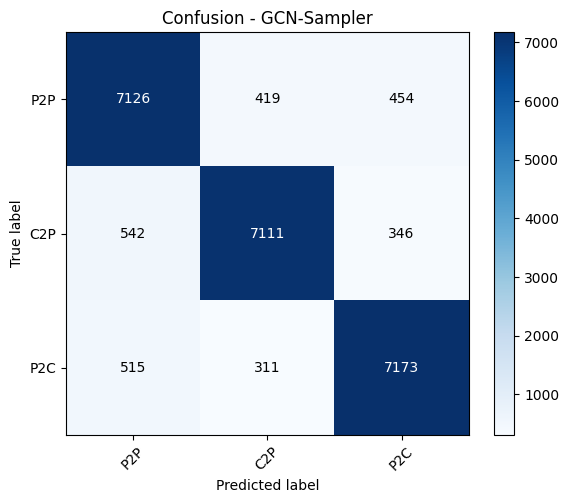

Normalized confusion matrix (%)


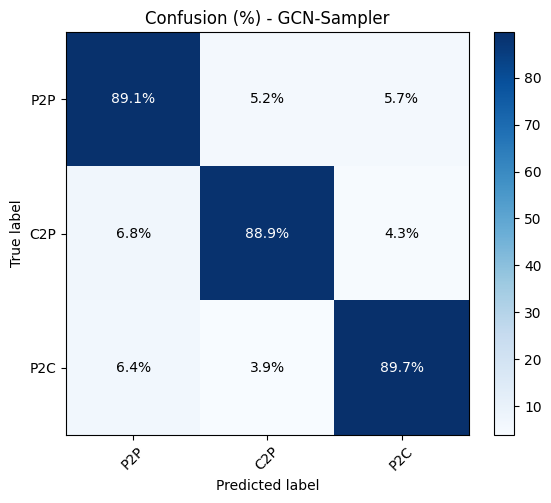

              precision    recall  f1-score   support

         P2P     0.8708    0.8909    0.8807      7999
         C2P     0.9069    0.8890    0.8979      7999
         P2C     0.8997    0.8967    0.8982      7999

    accuracy                         0.8922     23997
   macro avg     0.8925    0.8922    0.8923     23997
weighted avg     0.8925    0.8922    0.8923     23997



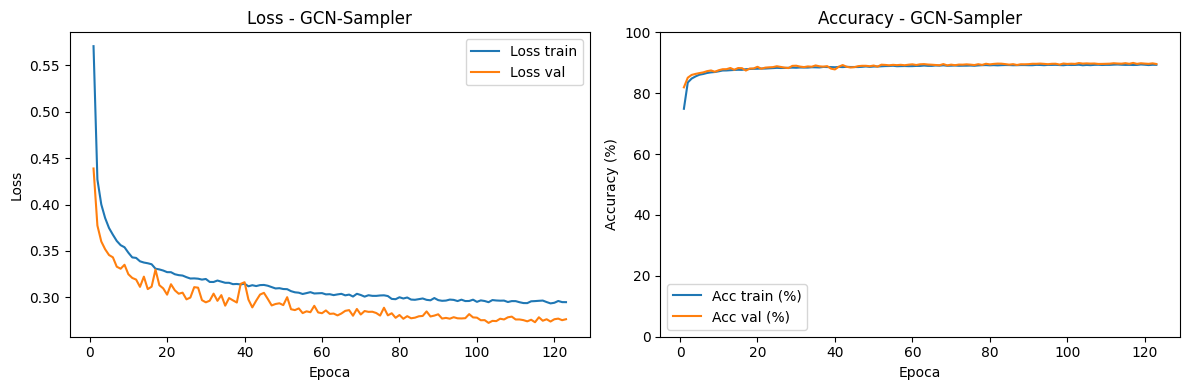


===== Entrenando SAGE-Sampler =====


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/dgl/dataloading/dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(


Epoch 001:   0%|          | 0/375 [00:00<?, ?it/s]

ep001 | loss_tr 0.6255  acc_tr 73.68% | loss_val 0.4420  acc_val 83.13%


Epoch 002:   0%|          | 0/375 [00:00<?, ?it/s]

...

Epoch 112:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 113:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 114:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 115:   0%|          | 0/375 [00:00<?, ?it/s]

Early-stop en epoca 115
Confusion matrix (not normalized)


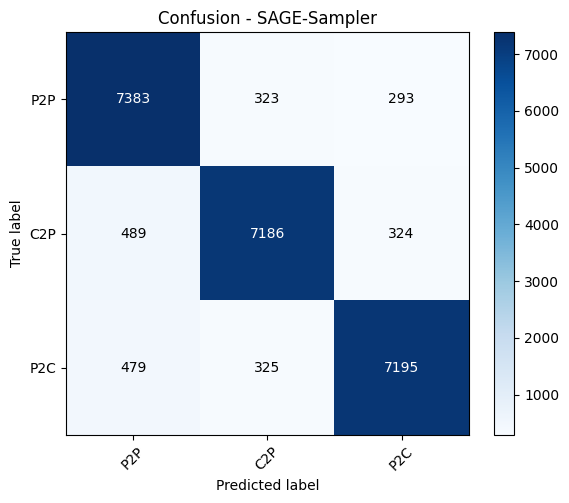

Normalized confusion matrix (%)


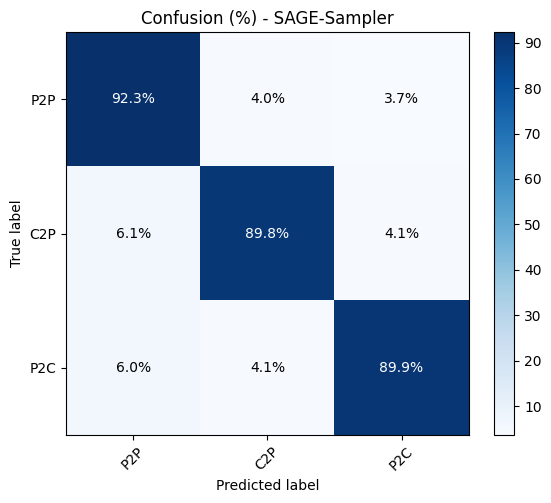

              precision    recall  f1-score   support

         P2P     0.8841    0.9230    0.9031      7999
         C2P     0.9173    0.8984    0.9077      7999
         P2C     0.9210    0.8995    0.9101      7999

    accuracy                         0.9069     23997
   macro avg     0.9075    0.9069    0.9070     23997
weighted avg     0.9075    0.9069    0.9070     23997



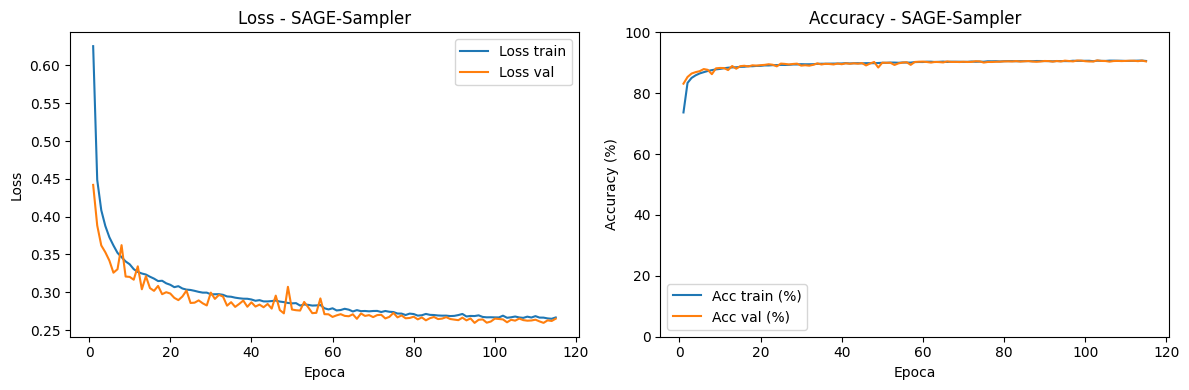


===== Entrenando GAT-Sampler =====


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/dgl/dataloading/dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(


Epoch 001:   0%|          | 0/375 [00:00<?, ?it/s]

ep001 | loss_tr 0.6535  acc_tr 73.31% | loss_val 0.5092  acc_val 80.44%


Epoch 002:   0%|          | 0/375 [00:00<?, ?it/s]

...

Epoch 162:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 163:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 164:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 165:   0%|          | 0/375 [00:00<?, ?it/s]

Early-stop en epoca 165
Confusion matrix (not normalized)


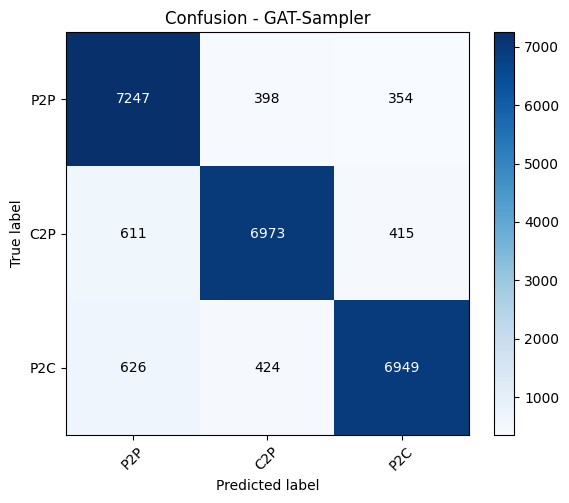

Normalized confusion matrix (%)


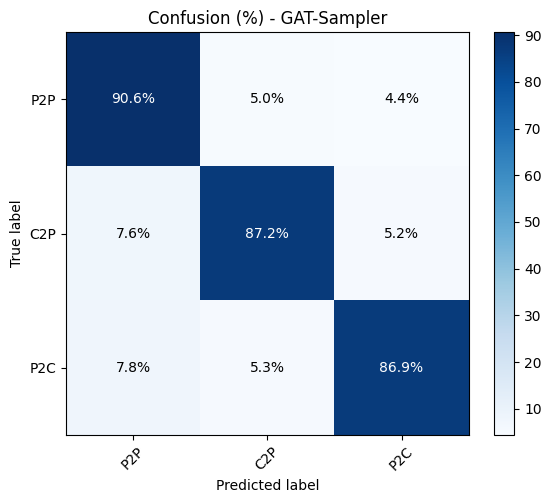

              precision    recall  f1-score   support

         P2P     0.8542    0.9060    0.8793      7999
         C2P     0.8945    0.8717    0.8830      7999
         P2C     0.9004    0.8687    0.8843      7999

    accuracy                         0.8822     23997
   macro avg     0.8830    0.8822    0.8822     23997
weighted avg     0.8830    0.8822    0.8822     23997



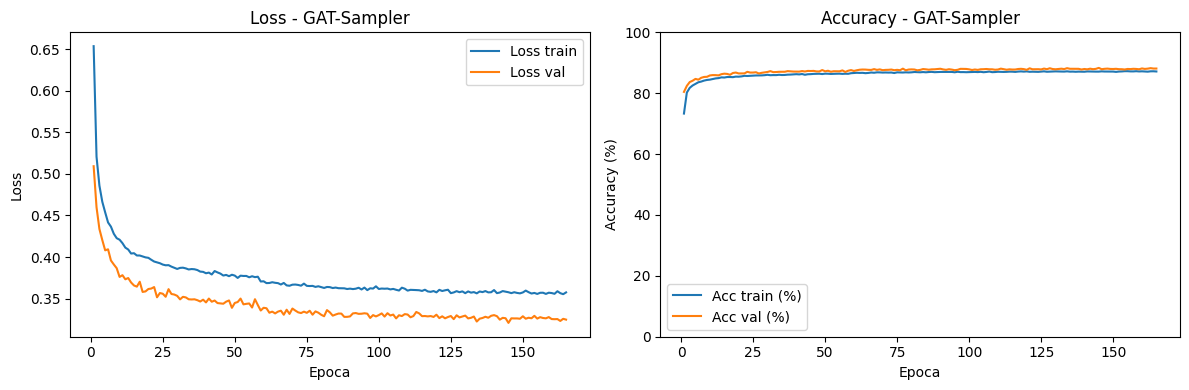

In [38]:
from tqdm.auto import tqdm
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

in_feats  = gnn.dgl_graph.ndata['feat'].shape[1]
n_classes = 3

for name, Model in models.items():
    print(f"\n===== Entrenando {name} =====")

    model     = Model(in_feats, HIDDEN_DIM, OUT_DIM, out_feats_mlp=n_classes).to(device)
    optim     = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, 'min', patience=8, factor=0.5)

    hist = {"loss_tr": [], "acc_tr": [], "loss_val": [], "acc_val": []}
    best_loss, best_state, wait = 1e9, None, 0

    for epoch in range(1, NUM_EPOCHS + 1):

        # ── TRAIN ──────────────────────────────────────────────────────
        model.train()
        loss_sum = corr = tot = 0

        for _, pair_graph, blocks in tqdm(train_loader, desc=f"Epoch {epoch:03d}", leave=False):
            x      = blocks[0].srcdata['feat']         # features de nodos de entrada
            labels = pair_graph.edata['label'].long()  # etiquetas de aristas del batch

            h      = model.encode(blocks, x)           # embeddings via neighbor sampling
            logits = model.decodeMLP(pair_graph, h)    # logits por arista (batch_size, 3)
            loss   = F.cross_entropy(logits, labels)

            optim.zero_grad()
            loss.backward()
            optim.step()

            loss_sum += loss.item() * len(labels)
            corr     += (logits.argmax(1) == labels).sum().item()
            tot      += len(labels)

        loss_tr = loss_sum / tot if tot > 0 else 0.0
        acc_tr  = 100 * corr / tot if tot > 0 else 0.0

        # ── VALIDACIÓN ─────────────────────────────────────────────────
        model.eval()
        loss_sum = corr = tot = 0

        with torch.no_grad():
            for _, pair_graph, blocks in val_loader:
                x      = blocks[0].srcdata['feat']
                labels = pair_graph.edata['label'].long()

                h      = model.encode(blocks, x)
                logits = model.decodeMLP(pair_graph, h)

                loss_sum += F.cross_entropy(logits, labels).item() * len(labels)
                corr     += (logits.argmax(1) == labels).sum().item()
                tot      += len(labels)

        loss_val = loss_sum / tot if tot > 0 else 0.0
        acc_val  = 100 * corr / tot if tot > 0 else 0.0

        scheduler.step(loss_val)

        hist['loss_tr'].append(loss_tr);   hist['acc_tr'].append(acc_tr)
        hist['loss_val'].append(loss_val); hist['acc_val'].append(acc_val)

        # Early stopping basado en val loss
        if loss_val < best_loss - 1e-4:
            best_loss, wait = loss_val, 0
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early-stop en epoca {epoch}")
                break

        if epoch % 5 == 0 or epoch == 1:
            print(f"ep{epoch:03d} | loss_tr {loss_tr:.4f}  acc_tr {acc_tr:.2f}% | "
                  f"loss_val {loss_val:.4f}  acc_val {acc_val:.2f}%")

    # ── EVALUACION FINAL (test) ────────────────────────────────────────
    model.load_state_dict(best_state)
    model.eval()
    preds_all, truth_all = [], []

    with torch.no_grad():
        for _, pair_graph, blocks in test_loader:
            x      = blocks[0].srcdata['feat']
            labels = pair_graph.edata['label'].long()

            h      = model.encode(blocks, x)
            logits = model.decodeMLP(pair_graph, h)

            preds_all.append(logits.argmax(1).cpu())
            truth_all.append(labels.cpu())

    preds = torch.cat(preds_all)
    truth = torch.cat(truth_all)

    cm = confusion_matrix(truth, preds)
    plot_confusion_matrix_2(cm, ["P2P","C2P","P2C"], normalize=False, title=f"Confusion - {name}")
    plot_confusion_matrix_2(cm, ["P2P","C2P","P2C"], normalize=True,  title=f"Confusion (%) - {name}")
    print(classification_report(truth, preds, digits=4, target_names=["P2P","C2P","P2C"]))

    # ── Curvas de entrenamiento ────────────────────────────────────────
    ep_axis = range(1, len(hist['loss_tr']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(ep_axis, hist['loss_tr'],  label='Loss train')
    axes[0].plot(ep_axis, hist['loss_val'], label='Loss val')
    axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss - {name}'); axes[0].legend()

    axes[1].plot(ep_axis, hist['acc_tr'],  label='Acc train (%)')
    axes[1].plot(ep_axis, hist['acc_val'], label='Acc val (%)')
    axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_ylim(0, 100)
    axes[1].set_title(f'Accuracy - {name}'); axes[1].legend()

    plt.tight_layout(); plt.show()


## Caso 3: Se utiliza grafo con atributos de PeeringDB y muestreo basado en comunidades (ClusterGCN)

In [11]:
from modules.gnn_models import GCNSampler, GraphSAGESample, GATSample

models = {
    "GCN-Sampler":  GCNSampler,
    "SAGE-Sampler": GraphSAGESample,
    "GAT-Sampler":  GATSample
}


# Configuración de entrenamiento (estable)
LR = 1e-3
HIDDEN_DIM = 64
OUT_DIM = 32
PATIENCE = 12
NUM_EPOCHS = 200

In [12]:
# 1. Load data with the new format (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))

gnn.split_edges_classification(
    train_size=0.8,
    val_size=0.15,
    seed=42,
    balance_mode="strict_equal",   # use "proportional" to keep natural class distribution
)

g0 = gnn.dgl_graph
print("\n[Loaded graph summary]")
print(f"- Nodes: {g0.num_nodes():,}")
print(f"- Edges: {g0.num_edges():,}")
print(f"- Feature dimension: {g0.ndata['feat'].shape[1]}")
print(f"- Edge data keys: {list(g0.edata.keys())}")
print(f"- Train edges: {g0.edata['train_mask'].sum().item():,}")
print(f"- Validation edges: {g0.edata['val_mask'].sum().item():,}")
print(f"- Test edges: {g0.edata['test_mask'].sum().item():,}")
if "label" in g0.edata:
    print(f"- Global label distribution: {Counter(g0.edata['label'].tolist())}")
    tr = g0.edata['label'][g0.edata['train_mask']]
    va = g0.edata['label'][g0.edata['val_mask']]
    te = g0.edata['label'][g0.edata['test_mask']]
    print(f"- Train distribution: {Counter(tr.tolist())}")
    print(f"- Validation distribution: {Counter(va.tolist())}")
    print(f"- Test distribution: {Counter(te.tolist())}")


Grafo cargado: 79504 nodos, 734381 aristas
Dimensión de entrada (in_feats): 72

[SPLIT COMPLETO - ESTRATIFICADO]
Modo balanceo: strict_equal
Etiqueta usada: label
Total aristas etiquetadas: 660438
Train: 383910 | Val: 71982 | Test: 23997
Distribución Train: {1: 127970, 0: 127970, 2: 127970}
Distribución Val:   {0: 23994, 2: 23994, 1: 23994}
Distribución Test:  {2: 7999, 1: 7999, 0: 7999}

[Loaded graph summary]
- Nodes: 79,504
- Edges: 734,381
- Feature dimension: 72
- Edge data keys: ['label', 'train_mask', 'val_mask', 'test_mask']
- Train edges: 383,910
- Validation edges: 71,982
- Test edges: 23,997
- Global label distribution: Counter({0: 340512, 1: 159963, 2: 159963, -1: 73943})
- Train distribution: Counter({1: 127970, 2: 127970, 0: 127970})
- Validation distribution: Counter({1: 23994, 0: 23994, 2: 23994})
- Test distribution: Counter({1: 7999, 0: 7999, 2: 7999})


In [ ]:
num_parts = 1000
device    = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

sampler = dgl.dataloading.ClusterGCNSampler(
    gnn.dgl_graph, num_parts,
    prefetch_ndata=['feat'],
    prefetch_edata=['label', 'train_mask', 'val_mask', 'test_mask']
)

cluster_ids = torch.arange(num_parts)

train_loader = dgl.dataloading.DataLoader(
    gnn.dgl_graph, 
    cluster_ids, sampler,
    batch_size=BATCH_SIZE, 
    shuffle=True,  
    drop_last=False, 
    device=device)

val_loader = dgl.dataloading.DataLoader(
    gnn.dgl_graph, 
    cluster_ids, 
    sampler,
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    drop_last=False, 
    device=device)

test_loader = dgl.dataloading.DataLoader(
    gnn.dgl_graph, 
    cluster_ids, 
    sampler,
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    drop_last=False, 
    device=device)

print(f"Device:      {device}")
print(f"Clusters:    {num_parts}  |  Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")


Device:      cpu
Clusters:    1000  |  Batch size: 32
Train batches: 32  |  Val batches: 32  |  Test batches: 32



===== Entrenando GCN-Sampler =====


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/dgl/dataloading/dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(


Epoch 001:   0%|          | 0/32 [00:00<?, ?it/s]

ep001 | loss_tr 0.7242  acc_tr 69.09% | loss_val 0.6278  acc_val 73.54%


Epoch 002:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 080:   0%|          | 0/32 [00:00<?, ?it/s]

ep080 | loss_tr 0.2100  acc_tr 92.72% | loss_val 0.2247  acc_val 92.00%


Epoch 081:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 082:   0%|          | 0/32 [00:00<?, ?it/s]

Early-stop en época 82
Confusion matrix (not normalized)


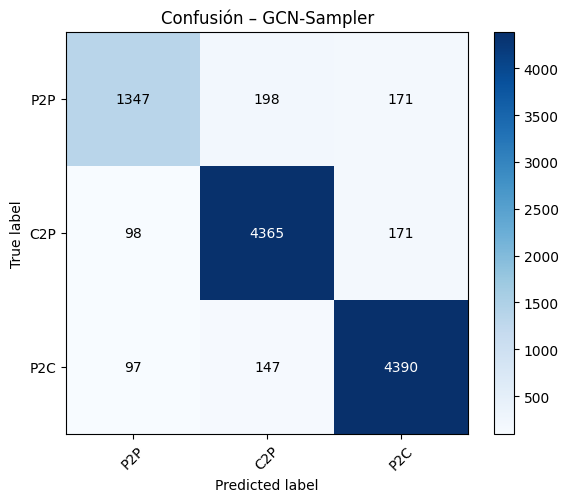

Normalized confusion matrix (%)


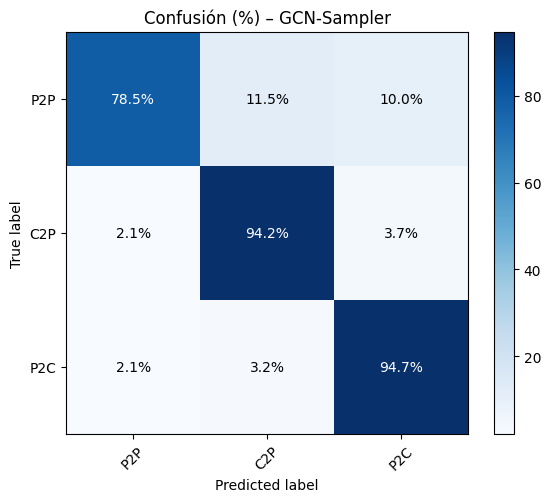

              precision    recall  f1-score   support

         P2P     0.8735    0.7850    0.8269      1716
         C2P     0.9268    0.9420    0.9343      4634
         P2C     0.9277    0.9473    0.9374      4634

    accuracy                         0.9197     10984
   macro avg     0.9093    0.8914    0.8995     10984
weighted avg     0.9188    0.9197    0.9188     10984



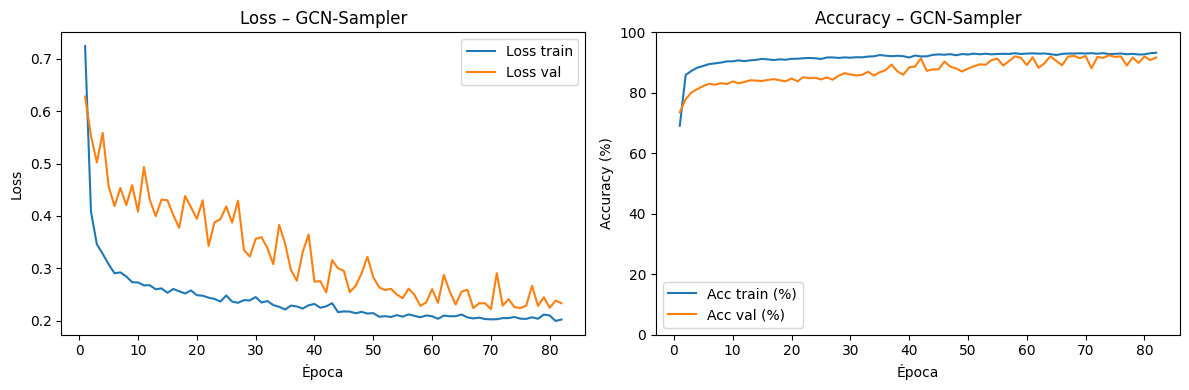


===== Entrenando SAGE-Sampler =====


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/dgl/dataloading/dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(


Epoch 001:   0%|          | 0/32 [00:00<?, ?it/s]

ep001 | loss_tr 0.8954  acc_tr 63.28% | loss_val 0.7548  acc_val 72.95%


Epoch 002:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 036:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 037:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 038:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 039:   0%|          | 0/32 [00:00<?, ?it/s]

Early-stop en época 39
Confusion matrix (not normalized)


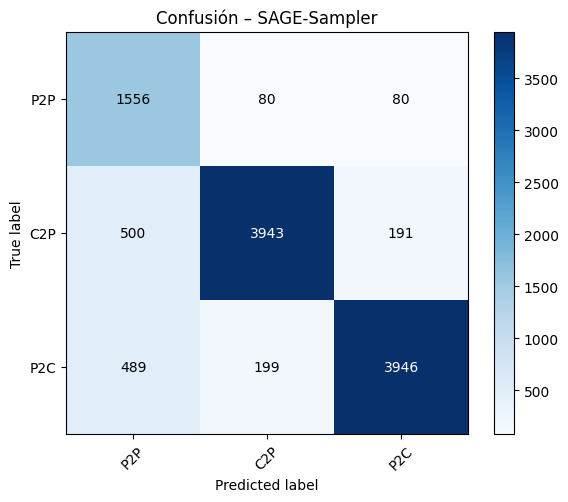

Normalized confusion matrix (%)


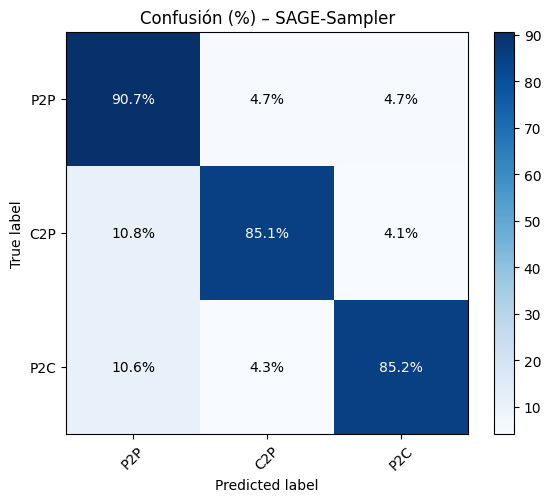

              precision    recall  f1-score   support

         P2P     0.6114    0.9068    0.7303      1716
         C2P     0.9339    0.8509    0.8905      4634
         P2C     0.9357    0.8515    0.8917      4634

    accuracy                         0.8599     10984
   macro avg     0.8270    0.8697    0.8375     10984
weighted avg     0.8843    0.8599    0.8660     10984



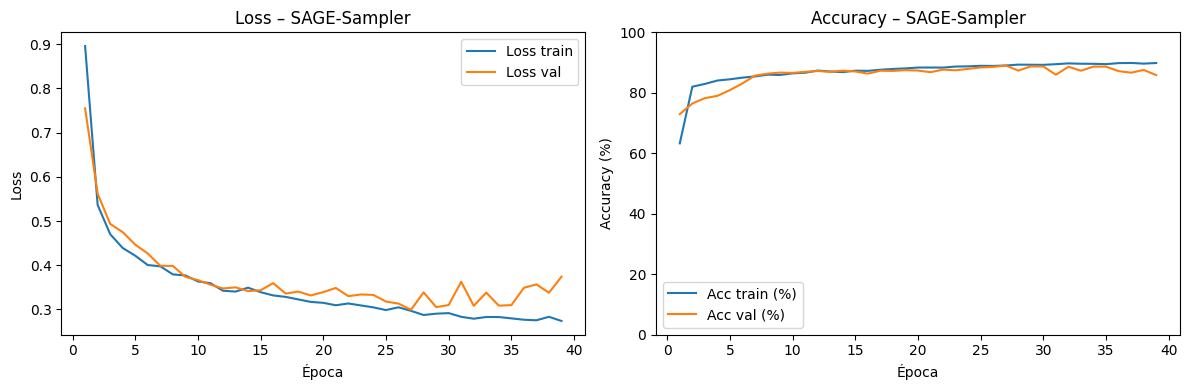


===== Entrenando GAT-Sampler =====


/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/dgl/dataloading/dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(


Epoch 001:   0%|          | 0/32 [00:00<?, ?it/s]

ep001 | loss_tr 0.8265  acc_tr 69.92% | loss_val 0.6535  acc_val 75.50%


Epoch 002:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 051:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 052:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 053:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 054:   0%|          | 0/32 [00:00<?, ?it/s]

Early-stop en época 54
Confusion matrix (not normalized)


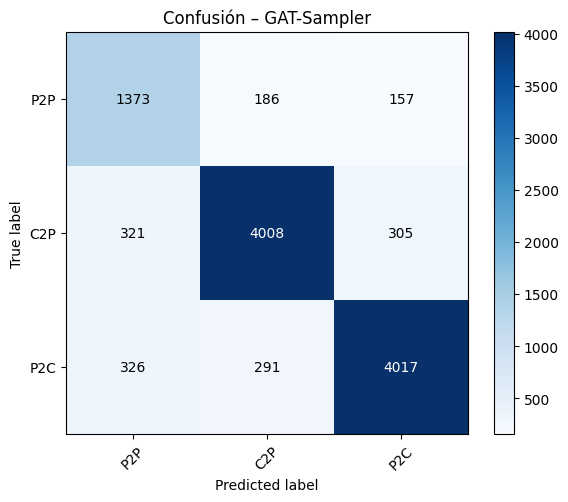

Normalized confusion matrix (%)


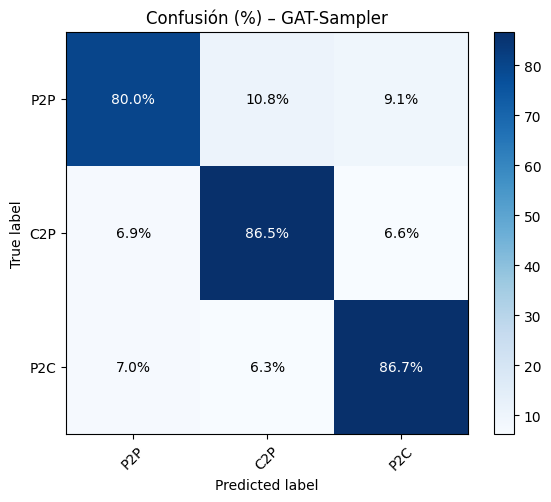

              precision    recall  f1-score   support

         P2P     0.6797    0.8001    0.7350      1716
         C2P     0.8936    0.8649    0.8790      4634
         P2C     0.8969    0.8669    0.8816      4634

    accuracy                         0.8556     10984
   macro avg     0.8234    0.8440    0.8319     10984
weighted avg     0.8616    0.8556    0.8576     10984



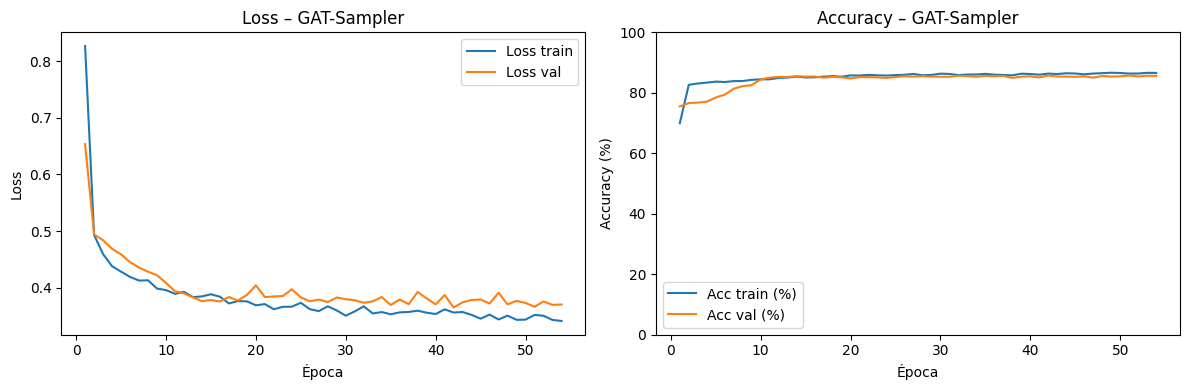

In [14]:
from tqdm.auto import tqdm
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

in_feats  = gnn.dgl_graph.ndata['feat'].shape[1]
n_classes = 3

for name, Model in models.items():
    print(f"\n===== Entrenando {name} =====")

    model    = Model(in_feats, HIDDEN_DIM, OUT_DIM, out_feats_mlp=n_classes).to(device)
    optim    = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, 'min', patience=8, factor=0.5)

    hist = {"loss_tr": [], "acc_tr": [], "loss_val": [], "acc_val": []}
    best_loss, best_state, wait = 1e9, None, 0

    for epoch in range(1, NUM_EPOCHS + 1):

        # ── TRAIN ──────────────────────────────────────────────────────────
        model.train()
        loss_sum = corr = tot = 0

        for subg in tqdm(train_loader, desc=f"Epoch {epoch:03d}", leave=False):
            if subg.num_edges() == 0:
                continue
            x = subg.ndata['feat'].float()
            y = subg.edata['label'].long()
            m = subg.edata['train_mask'].bool()
            if m.sum() == 0:
                continue

            h      = model.encode(subg, x)
            logits = model.decodeMLP(subg, h)
            loss   = F.cross_entropy(logits[m], y[m])

            optim.zero_grad()
            loss.backward()
            optim.step()

            loss_sum += loss.item() * m.sum().item()
            corr     += (logits[m].argmax(1) == y[m]).sum().item()
            tot      += m.sum().item()

        loss_tr = loss_sum / tot if tot > 0 else 0.0
        acc_tr  = 100 * corr / tot if tot > 0 else 0.0

        # ── VALIDACIÓN ─────────────────────────────────────────────────────
        model.eval()
        loss_sum = corr = tot = 0

        with torch.no_grad():
            for subg in val_loader:
                if subg.num_edges() == 0:
                    continue
                x = subg.ndata['feat'].float()
                y = subg.edata['label'].long()
                m = subg.edata['val_mask'].bool()
                if m.sum() == 0:
                    continue

                h      = model.encode(subg, x)
                logits = model.decodeMLP(subg, h)

                loss_sum += F.cross_entropy(logits[m], y[m]).item() * m.sum().item()
                corr     += (logits[m].argmax(1) == y[m]).sum().item()
                tot      += m.sum().item()

        loss_val = loss_sum / tot if tot > 0 else 0.0
        acc_val  = 100 * corr / tot if tot > 0 else 0.0

        scheduler.step(loss_val)

        hist['loss_tr'].append(loss_tr);   hist['acc_tr'].append(acc_tr)
        hist['loss_val'].append(loss_val); hist['acc_val'].append(acc_val)

        # Early stopping basado en val loss
        if loss_val < best_loss - 1e-4:
            best_loss, wait = loss_val, 0
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early-stop en época {epoch}")
                break

        if epoch % 5 == 0 or epoch == 1:
            print(f"ep{epoch:03d} | loss_tr {loss_tr:.4f}  acc_tr {acc_tr:.2f}% | "
                  f"loss_val {loss_val:.4f}  acc_val {acc_val:.2f}%")

    # ── EVALUACIÓN FINAL (test) ────────────────────────────────────────────
    model.load_state_dict(best_state)
    model.eval()
    preds_all, truth_all = [], []

    with torch.no_grad():
        for subg in test_loader:
            if subg.num_edges() == 0:
                continue
            x = subg.ndata['feat'].float()
            y = subg.edata['label'].long()
            m = subg.edata['test_mask'].bool()
            if m.sum() == 0:
                continue

            h      = model.encode(subg, x)
            logits = model.decodeMLP(subg, h)

            preds_all.append(logits[m].argmax(1).cpu())
            truth_all.append(y[m].cpu())

    preds = torch.cat(preds_all)
    truth = torch.cat(truth_all)

    cm = confusion_matrix(truth, preds)
    plot_confusion_matrix_2(cm, ["P2P","C2P","P2C"], normalize=False, title=f"Confusión – {name}")
    plot_confusion_matrix_2(cm, ["P2P","C2P","P2C"], normalize=True,  title=f"Confusión (%) – {name}")
    print(classification_report(truth, preds, digits=4, target_names=["P2P","C2P","P2C"]))

    # ── Curvas de entrenamiento ────────────────────────────────────────────
    ep_axis = range(1, len(hist['loss_tr']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(ep_axis, hist['loss_tr'],  label='Loss train')
    axes[0].plot(ep_axis, hist['loss_val'], label='Loss val')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss – {name}'); axes[0].legend()

    axes[1].plot(ep_axis, hist['acc_tr'],  label='Acc train (%)')
    axes[1].plot(ep_axis, hist['acc_val'], label='Acc val (%)')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_ylim(0, 100)
    axes[1].set_title(f'Accuracy – {name}'); axes[1].legend()

    plt.tight_layout(); plt.show()


## Caso 4: Se utiliza grafo con atributos de nodos generados aleatoriamente

In [5]:
models = {
    'GCN': GCN,
    'GraphSAGE': GraphSAGE,
    'GAT': GAT,
}


# Configuración de entrenamiento (estable)
LR = 1e-3
HIDDEN_DIM = 64
OUT_DIM = 32
PATIENCE = 12
NUM_EPOCHS = 200


# 1. Load data with the new format (node_id/asn + src_id/dst_id/relationship)
gnn = GNN(debug=True)
gnn.load_dataset(str(nodes_file), str(edges_file))


gnn.add_random_features(dim=64, std=0.05, seed=42, mode="uniform")


gnn.split_edges_classification(
    train_size=0.8,
    val_size=0.15,
    seed=42,
    balance_mode="strict_equal",   # use "proportional" to keep natural class distribution
)

g0 = gnn.dgl_graph

Grafo cargado: 79504 nodos, 734381 aristas
Dimensión de entrada (in_feats): 72
[add_random_features] feat ← (79504, 64)  |  mode=uniform

[SPLIT COMPLETO - ESTRATIFICADO]
Modo balanceo: strict_equal
Etiqueta usada: label
Total aristas etiquetadas: 660438
Train: 383910 | Val: 71982 | Test: 23997
Distribución Train: {1: 127970, 0: 127970, 2: 127970}
Distribución Val:   {0: 23994, 2: 23994, 1: 23994}
Distribución Test:  {2: 7999, 1: 7999, 0: 7999}



 Training GCN 
 ---------------
ep01 | loss_tr 1.1260 acc_tr 33.51% | loss_te 1.0273 acc_te 38.55%
ep10 | loss_tr 0.8071 acc_tr 65.01% | loss_te 0.7918 acc_te 76.25%
ep20 | loss_tr 0.5603 acc_tr 76.48% | loss_te 0.4707 acc_te 82.05%
ep30 | loss_tr 0.4171 acc_tr 85.84% | loss_te 0.5426 acc_te 80.82%
Early stop en época 37
Confusion matrix (not normalized)


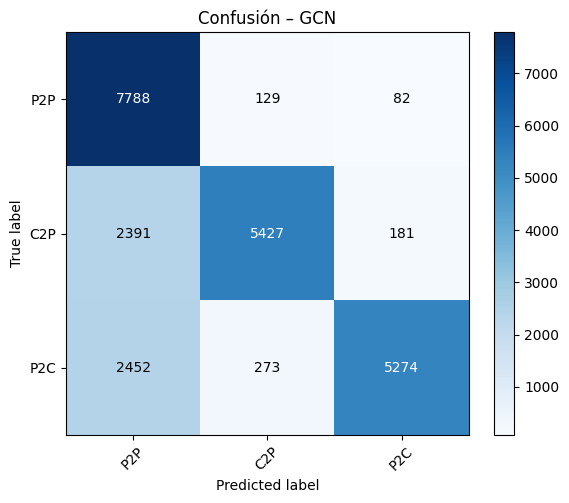

Normalized confusion matrix (%)


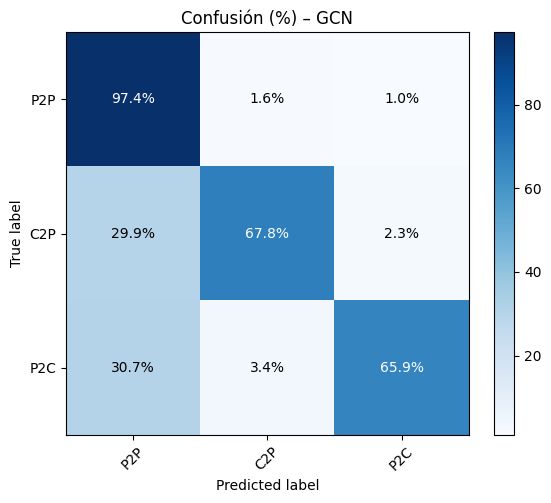

              precision    recall  f1-score   support

           0     0.6166    0.9736    0.7550      7999
           1     0.9310    0.6785    0.7849      7999
           2     0.9525    0.6593    0.7793      7999

    accuracy                         0.7705     23997
   macro avg     0.8334    0.7705    0.7731     23997
weighted avg     0.8334    0.7705    0.7731     23997



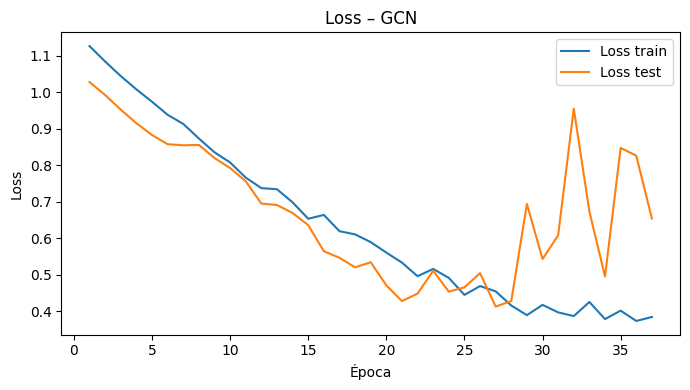

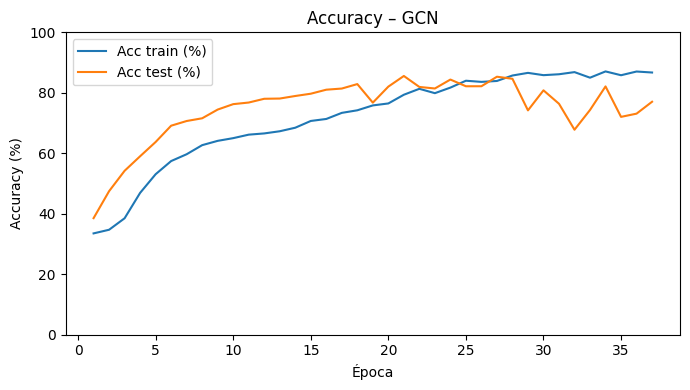


 Training GraphSAGE 
 ---------------
ep01 | loss_tr 1.1120 acc_tr 34.46% | loss_te 1.1039 acc_te 34.56%
ep10 | loss_tr 0.8461 acc_tr 60.50% | loss_te 0.8742 acc_te 65.00%
ep20 | loss_tr 0.5836 acc_tr 78.97% | loss_te 1.0125 acc_te 57.91%
Early stop en época 24
Confusion matrix (not normalized)


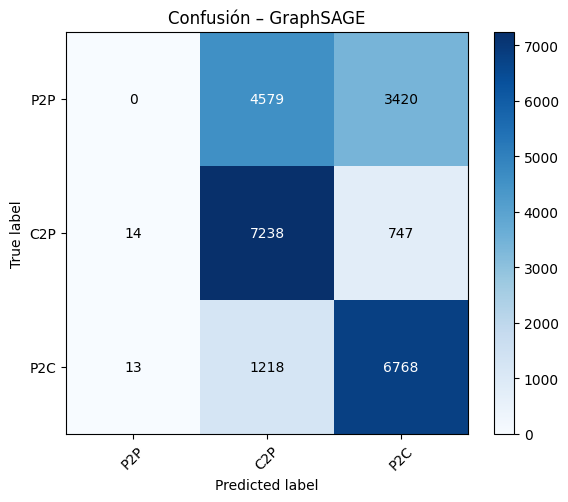

Normalized confusion matrix (%)


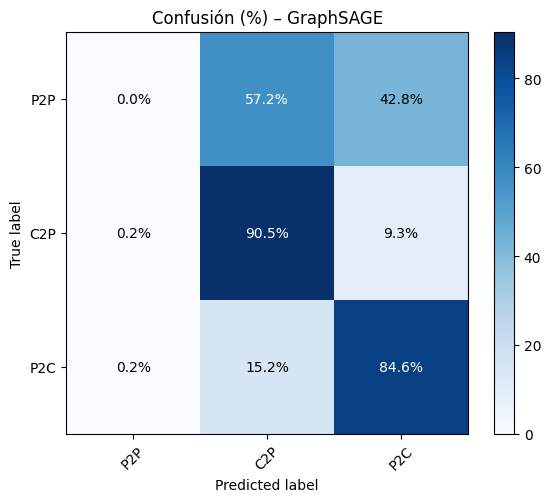

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      7999
           1     0.5553    0.9049    0.6882      7999
           2     0.6189    0.8461    0.7149      7999

    accuracy                         0.5837     23997
   macro avg     0.3914    0.5837    0.4677     23997
weighted avg     0.3914    0.5837    0.4677     23997



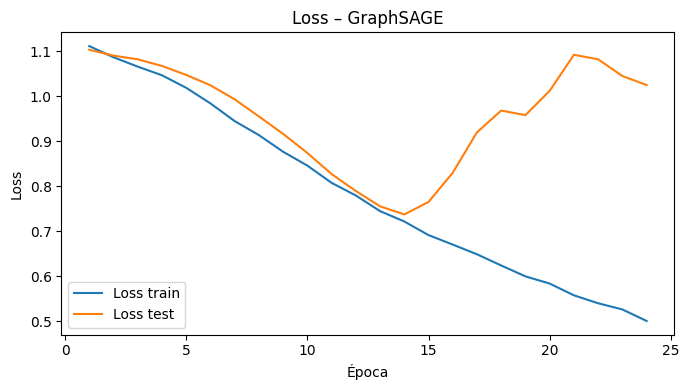

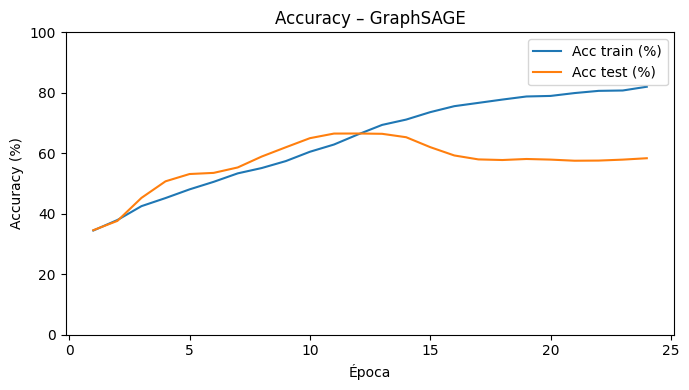


 Training GAT 
 ---------------
ep01 | loss_tr 1.1692 acc_tr 34.15% | loss_te 1.0981 acc_te 30.90%
ep10 | loss_tr 0.7112 acc_tr 76.37% | loss_te 1.2077 acc_te 50.25%
Early stop en época 11
Confusion matrix (not normalized)


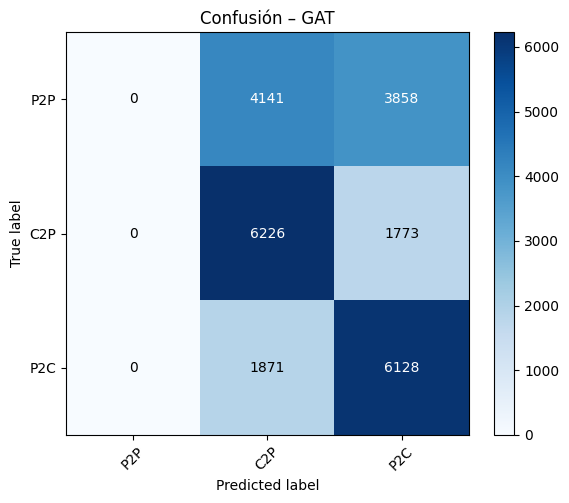

Normalized confusion matrix (%)


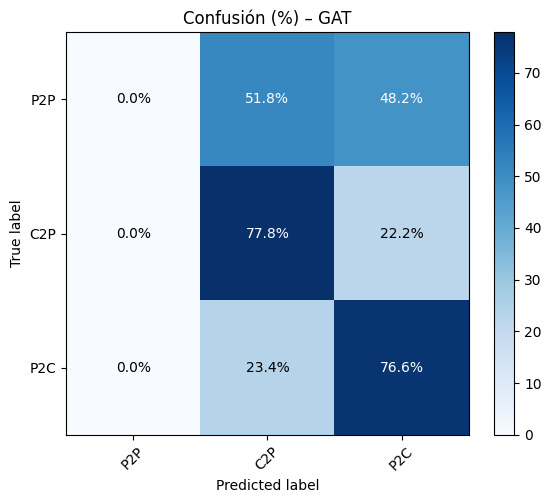

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      7999
           1     0.5087    0.7783    0.6153      7999
           2     0.5211    0.7661    0.6203      7999

    accuracy                         0.5148     23997
   macro avg     0.3433    0.5148    0.4119     23997
weighted avg     0.3433    0.5148    0.4119     23997



/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vale/Escritorio/GIT/TrabajoTesis/env310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

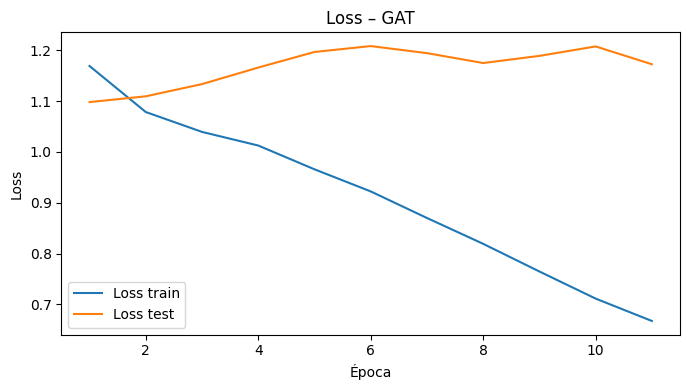

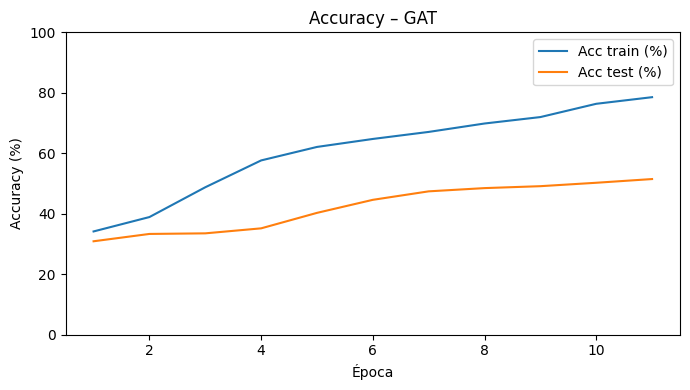

In [6]:
import torch, torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Parámetros 
# ------------------------------------------
in_feats  = gnn.dgl_graph.ndata["feat"].shape[1]
device    = "cuda" if torch.cuda.is_available() else "cpu"
lr        = 0.01
patience  = 10           # early-stopping
n_classes = 3

# Datos y máscaras 
# ------------------------------------------
g       = gnn.dgl_graph.to(device)
feat    = g.ndata["feat"].to(device)
label_key = next((k for k in ["label", "relationship", "Relationship"] if k in g.edata), None)
labels  = g.edata[label_key].long().to(device)
train_m = g.edata["train_mask"].to(device)
test_m  = g.edata["test_mask"].to(device)

for name, Model in models.items():
    print(f"\n Training {name} \n ---------------")

    model = Model(in_feats, 32, 16, out_feats_mlp=n_classes).to(device)
    opt   = torch.optim.Adam(model.parameters() , lr=lr)

    # histórico por modelo
    hist = {"loss_tr": [], "acc_tr": [], "loss_te": [], "acc_te": []}
    best_loss, wait = 1e9, 0

    for ep in range(1, NUM_EPOCHS + 1):
        # Entrenamiento 
        # ----------
        model.train()
        h      = model.encode(g, feat)
        logits = model.decodeMLP(g, h)                  # (E, 3)

        loss   = F.cross_entropy(logits[train_m], labels[train_m])
        # loss   = F.cross_entropy(logits[train_m], labels[train_m], weight=class_weights)

        
        opt.zero_grad() 
        loss.backward()
        opt.step()

        with torch.no_grad():
            preds_tr = logits[train_m].argmax(1)
            acc_tr   = (preds_tr == labels[train_m]).float().mean().item()

        # ---------- test ----------
        model.eval()
        with torch.no_grad():
            logits_t = model.decodeMLP(g, model.encode(g, feat))
            loss_te  = F.cross_entropy(logits_t[test_m], labels[test_m])
            # loss_te  = F.cross_entropy(logits_t[test_m], labels[test_m], weight=class_weights)
            preds_t  = logits_t[test_m].argmax(1)
            acc_t    = (preds_t == labels[test_m]).float().mean().item()

        # guarda histórico
        hist["loss_tr"].append(loss.item())
        hist["acc_tr"].append(acc_tr * 100)
        hist["loss_te"].append(loss_te.item())
        hist["acc_te"].append(acc_t * 100)

        # early-stopping
        if loss_te < best_loss - 1e-4:
            best_loss, wait = loss_te, 0
            best_w = model.state_dict()
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stop en época {ep}")
                break

        if ep % 10 == 0 or ep == 1:
            print(f"ep{ep:02d} | loss_tr {loss:.4f} acc_tr {acc_tr:.2%} | "
                  f"loss_te {loss_te:.4f} acc_te {acc_t:.2%}")

    # ---------- evaluación final ----------
    model.load_state_dict(best_w)
    with torch.no_grad():
        logits_best = model.decodeMLP(g, model.encode(g, feat))
        preds_best  = logits_best[test_m].argmax(1).cpu()
        truth       = labels[test_m].cpu()

    cm = confusion_matrix(truth, preds_best)
    plot_confusion_matrix_2(cm, ["P2P","C2P","P2C"], False,
                            title=f"Confusión – {name}")
    plot_confusion_matrix_2(cm, ["P2P","C2P","P2C"], True,
                            title=f"Confusión (%) – {name}")

    print(classification_report(truth, preds_best, digits=4))

    # ---------- curvas de entrenamiento ----------
    epochs_done = range(1, len(hist["loss_tr"]) + 1)

    plt.figure(figsize=(7,4))
    plt.plot(epochs_done, hist["loss_tr"], label="Loss train")
    plt.plot(epochs_done, hist["loss_te"], label="Loss test")
    plt.xlabel("Época"); plt.ylabel("Loss"); plt.title(f"Loss – {name}")
    plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs_done, hist["acc_tr"], label="Acc train (%)")
    plt.plot(epochs_done, hist["acc_te"], label="Acc test (%)")
    plt.xlabel("Época"); plt.ylabel("Accuracy (%)"); plt.ylim(0,100)
    plt.title(f"Accuracy – {name}")
    plt.legend(); plt.tight_layout(); plt.show()


## PREGUNTAS:
* ¿Por que incluso con atributos aleatorios se obtiene una buena accuracy con la GCN?
* ¿Por qué usando random Neighbputhood se obtienen la mejor accuracy?¿Por qué ocurre eso?¿Qué nos dice?
* Al ocupar los attr creados aleatoriamente , opdemos ver q se van aprendindo de memoria y por lo msimo la acurracy ntre mas epochs se emṕieza a separara
* ¿Que informacion del grafo y las GNNS puedo sacar con estos rsulatdos?
* construir hatmap d correlacion entre atributos de perngdb y uno tmb para las centralidades